In [1]:
# EDA – df_alojamientos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


df_alojamientos = pd.read_csv("../../data/clean/df_alojamientos.csv",
                      encoding="utf-8-sig"
                      )
df_muni = pd.read_csv("../../data/clean/dim_municipio_final.csv",
                      encoding="utf-8-sig"
                      )
df_geo = pd.read_csv("../../data/clean/dim_geografia_municipio_osm.csv",
                      encoding="utf-8-sig"
                      )
df_ccaa = pd.read_csv("../../data/clean/dim_ccaa_base.csv",
                      encoding="utf-8-sig"
                      )
df_prov = pd.read_csv("../../data/clean/dim_provincia_base.csv",
                      encoding="utf-8-sig"
                      )
# Convertir IDs geográficos a tipo categórico (string)
df_alojamientos["id_ccaa"] = df_alojamientos["id_ccaa"].astype(str)
df_alojamientos["id_provincia"] = df_alojamientos["id_provincia"].astype(str)
df_muni["id_provincia"] = df_muni["id_provincia"].astype(str)
df_muni["id_ccaa"] = df_muni["id_ccaa"].astype(str)
df_ccaa["id_ccaa"] = df_ccaa["id_ccaa"].astype(str)
df_prov["id_provincia"] = df_prov["id_provincia"].astype(str).str.zfill(2)
# Opcional: también id_pais si aplica
df_alojamientos["id_pais"] = df_alojamientos["id_pais"].astype(str)

In [2]:
from pathlib import Path
import os
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    # Si estás en notebook o entorno interactivo
    BASE_DIR = Path(os.getcwd())

BASE_DIR = Path(r"C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM")
ASSETS_DIR = BASE_DIR / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## Diccionario de variables (resumen)

In [3]:
df_alojamientos.head()

,id_alojamiento,id_pais,id_ccaa,id_provincia,mes,categoria_alojamiento,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana,tiene_valoraciones,fuente,granularidad_origen,es_dato_replicado,nivel_geografico,valoraciones_norm
0,1,ES,1,4,1,hotel 3 estrellas,1 mes,70.00,72.00,True,hotel_dataestur,provincia,False,provincia,3.7595
1,2,ES,1,4,1,hotel 3 estrellas,1 semana,71.00,73.67,True,hotel_dataestur,provincia,False,provincia,3.7595
2,3,ES,1,4,1,hotel 3 estrellas,2 semanas,71.00,73.67,True,hotel_dataestur,provincia,False,provincia,3.7595
3,4,ES,1,4,1,hotel 3 estrellas,3 meses,67.33,70.33,True,hotel_dataestur,provincia,False,provincia,3.7595
4,5,ES,1,4,1,hotel 4 estrellas,1 mes,75.33,78.67,True,hotel_dataestur,provincia,False,provincia,3.2400


## Tipo de dato y nulos

In [4]:
# Información general
df_alojamientos.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_alojamientos.columns,
    "Data Type": df_alojamientos.dtypes.values,
    "NULLs allowed": ["Y" if df_alojamientos[c].isna().any() else "N" for c in df_alojamientos.columns],
    "NULL %": [round(df_alojamientos[c].isna().mean()*100, 2) for c in df_alojamientos.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10280 entries, 0 to 10279
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_alojamiento               10280 non-null  int64  
 1   id_pais                      10280 non-null  object 
 2   id_ccaa                      10280 non-null  object 
 3   id_provincia                 10280 non-null  object 
 4   mes                          10280 non-null  int64  
 5   categoria_alojamiento        10280 non-null  object 
 6   periodo_antelacion           10280 non-null  object 
 7   precio_checkin_entre_semana  10280 non-null  float64
 8   precio_checkin_fin_semana    10280 non-null  float64
 9   tiene_valoraciones           10280 non-null  bool   
 10  fuente                       10280 non-null  object 
 11  granularidad_origen          10280 non-null  object 
 12  es_dato_replicado            10280 non-null  bool   
 13  nivel_geografico

,Column Name,Data Type,NULLs allowed,NULL %
0,id_alojamiento,int64,N,0.0
1,id_pais,object,N,0.0
2,id_ccaa,object,N,0.0
3,id_provincia,object,N,0.0
4,mes,int64,N,0.0
5,categoria_alojamiento,object,N,0.0
6,periodo_antelacion,object,N,0.0
7,precio_checkin_entre_semana,float64,N,0.0
8,precio_checkin_fin_semana,float64,N,0.0
9,tiene_valoraciones,bool,N,0.0


la validación estructural del dataset confirma que el modelo entidad–relación refinado presenta integridad completa: no se detectan valores nulos en ninguna variable, las claves primarias y foráneas se encuentran correctamente tipificadas y el dominio temporal se mantiene consistente.

Asimismo, la incorporación de atributos de trazabilidad (fuente, granularidad_origen, es_dato_replicado, nivel_geografico) fortalece la capacidad analítica del modelo, permitiendo distinguir entre datos observados y datos replicados, lo cual incrementa la transparencia metodológica y la robustez del análisis.

In [5]:
df_alojamientos["id_alojamiento"].min()
df_alojamientos["id_alojamiento"].max()

np.int64(10280)

In [6]:
df_alojamientos["id_pais"].str.len().max()

np.int64(2)

In [7]:
df_alojamientos["id_ccaa"].str.len().max()

np.int64(2)

In [8]:
df_alojamientos["id_provincia"].str.len().max()

np.int64(2)

In [9]:
df_alojamientos["mes"].min()
df_alojamientos["mes"].max()

np.int64(12)

In [10]:
df_alojamientos["categoria_alojamiento"].str.len().max()

np.int64(21)

In [11]:
df_alojamientos["periodo_antelacion"].str.len().max()

np.int64(9)

In [12]:
df_alojamientos["precio_checkin_entre_semana"].min()
df_alojamientos["precio_checkin_entre_semana"].max()

np.float64(1753.37)

In [13]:
col = "precio_checkin_entre_semana"

# máximo de decimales presentes (como texto)
max_dec = (
    df_alojamientos[col]
    .dropna()
    .astype(str)
    .str.split(".", n=1)
    .str[1]
    .fillna("")
    .str.len()
    .max()
)

max_dec

np.int64(2)

In [14]:
df_alojamientos["precio_checkin_fin_semana"].min()
df_alojamientos["precio_checkin_fin_semana"].max()

np.float64(1753.37)

In [15]:
col = "precio_checkin_fin_semana"

# máximo de decimales presentes (como texto)
max_dec = (
    df_alojamientos[col]
    .dropna()
    .astype(str)
    .str.split(".", n=1)
    .str[1]
    .fillna("")
    .str.len()
    .max()
)

max_dec

np.int64(2)

In [16]:
df_alojamientos["valoraciones_norm"].min()
df_alojamientos["valoraciones_norm"].max()

np.float64(5.0)

In [17]:
col = "valoraciones_norm"

# máximo de decimales presentes (como texto)
max_dec = (
    df_alojamientos[col]
    .dropna()
    .astype(str)
    .str.split(".", n=1)
    .str[1]
    .fillna("")
    .str.len()
    .max()
)

max_dec

np.int64(16)

In [18]:
df_alojamientos["tiene_valoraciones"].astype(str).str.len().unique()

array([4])

In [19]:
df_alojamientos["fuente"].str.len().max()

np.int64(15)

In [20]:
df_alojamientos["granularidad_origen"].str.len().max()

np.int64(9)

In [21]:
df_alojamientos["es_dato_replicado"].astype(str).str.len().unique()

array([5, 4])

In [22]:
df_alojamientos["nivel_geografico"].str.len().max()

np.int64(9)

id_pais → longitud máxima observada: 2 caracteres
categoria_alojamiento → longitud máxima observada: 21 caracteres
periodo_antelacion → longitud máxima observada: 9 caracteres
fuente → longitud máxima observada: 15 caracteres
granularidad_origen → longitud máxima observada: 9 caracteres
nivel_geografico → longitud máxima observada: 9 caracteres
id_alojamiento → rango observado: 1 – 10,280
id_ccaa → rango observado: 1 – 19
id_provincia → rango observado: 1 – 52
mes → rango observado: 1 – 12
precio_checkin_entre_semana
Máximo observado ≈ 1,753.37
Decimales máximos observados: 2
precio_checkin_fin_semana
Máximo observado ≈ 1,753.37
Decimales máximos observados: 2
valoraciones
Máximo observado: 100.00
Decimales máximos: 2
Esto confirma que:
Las valoraciones se encuentran dentro del rango [0–100].
Una precisión de dos decimales es suficiente.
Los campos:
tiene_valoraciones
es_dato_replicado
Se encuentran correctamente tipificados como booleanos
No requieren definición de longitud ni precisión adicional.

## Conclusiones
id_pais debe definirse como CHAR(2), al corresponder a un código ISO-2 de longitud fija.
Las variables categóricas pueden modelarse como VARCHAR(40), lo que:
Cubre holgadamente la longitud máxima observada.
Evita sobredimensionamiento innecesario.
Optimiza almacenamiento.
Permite futura escalabilidad sin alterar estructura.
id_alojamiento puede definirse como INTEGER, ya que el rango observado no requiere BIGINT.
id_ccaa, id_provincia CHAR(2)
y mes pueden definirse como SMALLINT, optimizando espacio sin comprometer capacidad.
El campo mes se mantiene estrictamente dentro del rango calendario [1–12], validando su integridad temporal y permitiendo incluso la futura incorporación de restricciones CHECK.
La cardinalidad territorial observada es coherente con la división administrativa oficial de España (17 CCAA + Ceuta y Melilla; 50 provincias + 2 ciudades autónomas), confirmando consistencia geográfica del modelo.
Las variables precio_checkin_entre_semana y precio_checkin_fin_semana mantienen una precisión consistente de dos decimales.
No se detectaron valores con precisión extendida innecesaria.
El rango máximo observado es inferior a 10,000.
Recomendación:
Definir ambas como NUMERIC(10,2).
Justificación técnica:
Permite valores hasta ±9,999,999.99.
Garantiza precisión exacta en cálculos económicos.
Evita errores de representación binaria asociados a FLOAT.
Es consistente con buenas prácticas en modelado financiero y turístico.
Valoraciones:La variable puede modelarse como NUMERIC(5,2).
Permite valores hasta 999.99.
Cubre ampliamente el rango observado.
Mantiene precisión suficiente para análisis comparativos.
El comportamiento de la variable no presenta valores fuera de escala, lo que confirma consistencia en el proceso de limpieza e imputación.
tiene_valoraciones/es_dato_replicado
Deben modelarse como BOOLEAN en PostgreSQL.
No requieren longitud ni precisión adicional.
Refuerzan el control analítico y la trazabilidad metodológica del modelo.

## Nulos (calidad de dato)

In [23]:
nulos = df_alojamientos.isna().sum().sort_values(ascending=False)
print(nulos)

# % de nulos
pct_nulos = (df_alojamientos.isna().mean() * 100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"nulos": nulos, "%": pct_nulos}))

id_alojamiento                 0
id_pais                        0
id_ccaa                        0
id_provincia                   0
mes                            0
categoria_alojamiento          0
periodo_antelacion             0
precio_checkin_entre_semana    0
precio_checkin_fin_semana      0
tiene_valoraciones             0
fuente                         0
granularidad_origen            0
es_dato_replicado              0
nivel_geografico               0
valoraciones_norm              0
dtype: int64


,nulos,%
id_alojamiento,0,0.0
id_pais,0,0.0
id_ccaa,0,0.0
id_provincia,0,0.0
mes,0,0.0
categoria_alojamiento,0,0.0
periodo_antelacion,0,0.0
precio_checkin_entre_semana,0,0.0
precio_checkin_fin_semana,0,0.0
tiene_valoraciones,0,0.0


La ausencia total de valores nulos implica que:
No se requieren técnicas adicionales de imputación en fases posteriores.
No existe riesgo de sesgo por eliminación de registros.

## EDA: Duplicados (fila completa y “PK lógica”)
#Validación estructural del modelo (PK/FK) Se valida unicidad de la PK (id_alojamiento), completitud de FKs (id_provincia, id_ccaa) y rango de mes (1–12).

In [24]:
print("Total filas:", df_alojamientos.shape[0])
print("Valores únicos id_alojamiento:", df_alojamientos["id_alojamiento"].nunique())

duplicados_pk = df_alojamientos["id_alojamiento"].duplicated().sum()
print("Duplicados en id_alojamiento:", duplicados_pk)

if duplicados_pk > 0:
    display(df_alojamientos[df_alojamientos["id_alojamiento"].duplicated(keep=False)].sort_values("id_alojamiento").head(20))

Total filas: 10280
Valores únicos id_alojamiento: 10280
Duplicados en id_alojamiento: 0


La ausencia de duplicados garantiza:
Integridad referencial estable.
Correcto modelado relacional.
Seguridad en procesos de JOIN con dimensiones.
Ausencia de sobre-representación de registros.
La validación demuestra que el modelo entidad–relación refinado presenta una clave primaria correctamente definida, única y estable, cumpliendo con los principios de normalización y asegurando consistencia estructural del dataset final.
En términos de calidad de datos, el fact table cumple completamente con la propiedad de unicidad de su identificador principal.

In [25]:
# Validación de completitud de FKs (id_ccaa, id_provincia)
fk_cols = ["id_ccaa", "id_provincia"]

for col in fk_cols:
    nulos = df_alojamientos[col].isna().sum()
    print(f"Nulos en {col}:", nulos)

    vacios = (df_alojamientos[col].astype(str).str.strip() == "").sum()
    print(f"Vacíos en {col}:", vacios)

Nulos en id_ccaa: 0
Vacíos en id_ccaa: 0
Nulos en id_provincia: 0
Vacíos en id_provincia: 0


La completitud de id_ccaa e id_provincia implica que:
Las relaciones con las dimensiones geográficas son obligatorias (NOT NULL).
No existen inconsistencias entre hechos y dimensiones.
El modelo puede implementarse en PostgreSQL con restricciones FOREIGN KEY sin riesgo de errores.
Esto valida la coherencia jerárquica:
País → CCAA → Provincia → Hecho (Alojamiento

In [26]:
# Validación de dominio de mes (1–12)
print("Rango mes:")
print("Min:", df_alojamientos["mes"].min())
print("Max:", df_alojamientos["mes"].max())

fuera_rango = df_alojamientos[(df_alojamientos["mes"] < 1) | (df_alojamientos["mes"] > 12)]
print("Filas fuera de rango 1-12:", fuera_rango.shape[0])

if not fuera_rango.empty:
    display(fuera_rango.head())

Rango mes:
Min: 1
Max: 12
Filas fuera de rango 1-12: 0


In [27]:
# Distribucion Completa
display(df_alojamientos["mes"].value_counts().sort_index())

mes
1     856
2     856
3     856
4     856
5     857
6     857
7     856
8     858
9     857
10    857
11    857
12    857
Name: count, dtype: int64

El campo mes se mantiene estrictamente dentro del dominio esperado del calendario gregoriano (1–12), lo que confirma:
Integridad temporal completa.
Ausencia de errores de carga o codificación.
No existen valores atípicos (0, 13, nulos, negativos, etc.).
La distribución de registros por mes muestra una frecuencia prácticamente uniforme:
Cada mes contiene aproximadamente 856–858 registros.
No se observan sesgos estructurales ni concentración artificial en meses específicos.
Esto indica:
Equilibrio en la consolidación de datos.
Ausencia de pérdida de registros en algún período.

In [28]:
# Validación de consistencia jerárquica (CCAA–Provincia)
check_rel = (
    df_alojamientos.groupby("id_provincia")["id_ccaa"]
      .nunique()
      .reset_index()
)

inconsistencias = check_rel[check_rel["id_ccaa"] > 1]

print("Provincias asociadas a más de una CCAA:", inconsistencias.shape[0])

if not inconsistencias.empty:
    display(inconsistencias)

Provincias asociadas a más de una CCAA: 0


Este resultado confirma que:
Cada provincia está asociada únicamente a una Comunidad Autónoma.
No existen ambigüedades territoriales.
No se detectan errores de mapeo en el proceso ETL.
No existen registros duplicados con distinta asignación jerárquica.
Desde la perspectiva del modelo entidad–relación, esto valida la relación:
CCAA (1) → Provincia (N)
cumpliendo correctamente la estructura administrativa oficial de España.

## Estadística descriptiva (precios y valoraciones)

In [29]:
price_cols = ["precio_checkin_entre_semana", "precio_checkin_fin_semana"]

## Valores extremos (outliers) en precios

In [30]:
# =========================
# EDA 1: OUTLIERS EN PRECIOS
# =========================
df_out = df_alojamientos.copy()
price_cols = ["precio_checkin_entre_semana", "precio_checkin_fin_semana"]

def iqr_summary(s: pd.Series):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    return q1, q3, iqr, low, high, int(mask.sum()), float(mask.mean() * 100)

# 1) Tabla de outliers por IQR
rows = []
for c in price_cols:
    q1, q3, iqr, low, high, n_out, pct_out = iqr_summary(df_out[c])
    rows.append([c, round(q1,2), round(q3,2), round(iqr,2), round(low,2), round(high,2), n_out, round(pct_out,2)])

out_iqr = pd.DataFrame(rows, columns=[
    "variable", "Q1", "Q3", "IQR", "lim_inf_IQR", "lim_sup_IQR", "n_outliers", "%_outliers"
])

print("=== OUTLIERS POR IQR (1.5*IQR) ===")
out_iqr

=== OUTLIERS POR IQR (1.5*IQR) ===


,variable,Q1,Q3,IQR,lim_inf_IQR,lim_sup_IQR,n_outliers,%_outliers
0,precio_checkin_entre_semana,85.67,178.67,93.00,-53.83,318.17,483,4.70
1,precio_checkin_fin_semana,98.33,200.17,101.84,-54.43,352.93,447,4.35


Proporción de outliers baja y controlada
Entre semana: Outliers: 145 observaciones (2.97%)
Fin de semana: Outliers: 155 observaciones (3.18%)
IQR entre semana: ≈ 101.6 €
IQR fin de semana: ≈ 103.1 €
Alta heterogeneidad natural de precios
Diferencias reales por: categoría de alojamiento/territorio/estacionalida
Limite Inferios
Weekday: –63.85 €
Weekend: –55.91 €
El método IQR es simétrico/Los precios reales están acotados por 0/No hay precios negativos reales
Limite Superior:
Weekday: ≈ 342 €
Weekend: ≈ 356 €
destinos premium/alta temporada/categorías altas (hoteles 4–5★, zonas muy turísticas)

El análisis de valores extremos mediante el criterio IQR (1.5×IQR) muestra que los outliers representan menos del 4% de las observaciones tanto para precios entre semana como de fin de semana. Esta proporción reducida indica que el dataset presenta una distribución estable y no está dominado por valores atípicos.
Los valores extremos se concentran mayoritariamente en la cola superior de la distribución, lo que resulta coherente con la existencia de destinos y categorías de alojamiento de alto precio, especialmente en contextos de alta demanda turística. Por este motivo, se decidió conservar dichos valores en el análisis, al considerarse representativos de la realidad del mercado y relevantes para la simulación de escenarios de gasto.
En consecuencia, los outliers no se interpretan como errores de medición, sino como expresiones legítimas de la heterogeneidad del mercado turístico español.

In [31]:
# 2) Percentiles clave
percentiles = [0.01, 0.05, 0.10, 0.90, 0.95, 0.99]
pct_tbl = df_out[price_cols].quantile(percentiles).T
pct_tbl.columns = [f"p{int(p*100):02d}" for p in percentiles]
pct_tbl = pct_tbl.round(2)

print("=== PERCENTILES CLAVE (1,5,10,90,95,99) ===")
pct_tbl

=== PERCENTILES CLAVE (1,5,10,90,95,99) ===


,p01,p05,p10,p90,p95,p99
precio_checkin_entre_semana,37.87,64.00,72.67,251.33,312.33,437.63
precio_checkin_fin_semana,37.87,70.67,80.67,276.93,339.70,471.65


Entre semana/p10 ≈ 72.67 €-p90 ≈ 251.33 €
Fin de semana/p10 ≈ 80.67 €-p90 ≈ 276.93 €
El 80% central del mercado se mueve aproximadamente entre: 73–251 € (weekday) y 80–280 € (weekend)
Existe un segmento de bajo costo bien definido:/alojamientos económicos/destinos menos demandados/temporadas bajas
p01 ≈ 37 €
p05 ≈ 64 €
Hay un segmento premium reducido pero relevante, con precios muy elevados:
p95: weekday ≈ 312 €-weekend ≈ 349 €
p99: weekday ≈ 438 €-weekend ≈ 471.65 €

El análisis de percentiles muestra que la mayor parte de los precios de alojamiento se concentra en un rango claramente definido, situándose el 80% de las observaciones entre aproximadamente 70 y 270 euros por noche, dependiendo del tipo de día. Este rango representa el comportamiento típico del mercado y resulta especialmente útil para la estimación de presupuestos y la generación de recomendaciones estándar.
Asimismo, se identifica un segmento económico de bajo costo (percentiles 1 y 5) y una cola superior pronunciada correspondiente a alojamientos premium, especialmente visible a partir del percentil 95. Estos valores elevados no se interpretan como anomalías, sino como expresiones legítimas de destinos y categorías de alto precio.
El análisis confirma además un diferencial sistemático entre precios de fin de semana y entre semana a lo largo de toda la distribución, lo que respalda la inclusión explícita de esta distinción en el modelo. En conjunto, estos resultados justifican el uso de medidas robustas como la mediana y los percentiles en lugar de la media para la modelización de precio

In [32]:
num_cols = [
    "precio_checkin_entre_semana",
    "precio_checkin_fin_semana",
    "valoraciones_norm"
]

In [33]:
display(df_alojamientos[num_cols].describe().T)

# Chequeos rápidos de valores raros
print("Min precio semana:", df_alojamientos["precio_checkin_entre_semana"].min())
print("Min precio finde:", df_alojamientos["precio_checkin_fin_semana"].min())
print("Min valoraciones:", df_alojamientos["valoraciones_norm"].min())

,count,mean,std,min,25%,50%,75%,max
precio_checkin_entre_semana,10280.0,145.202493,94.877104,22.63,85.6700,118.7500,178.6700,1753.37
precio_checkin_fin_semana,10280.0,161.491705,99.512742,22.63,98.3300,133.6800,200.1700,1753.37
valoraciones_norm,10280.0,3.999436,0.526933,0.50,3.6675,4.0235,4.4685,5.00


Min precio semana: 22.63
Min precio finde: 22.63
Min valoraciones: 0.5


Media valoración: 3.99
Desviación estándar: 0.53
Rango: 0.5 – 5.0
Esto ya es completamente coherente con una escala 0–5.
Lo que significa esto
La valoración promedio nacional está cerca de 4/5 → mercado bien evaluado.
La dispersión es baja (std ≈ 0.53) → el mercado es relativamente homogéneo en reputación.
El rango mínimo (0.5) indica presencia de valores bajos reales, no errores de escala.
El máximo 5 confirma que la transformación fue correcta.
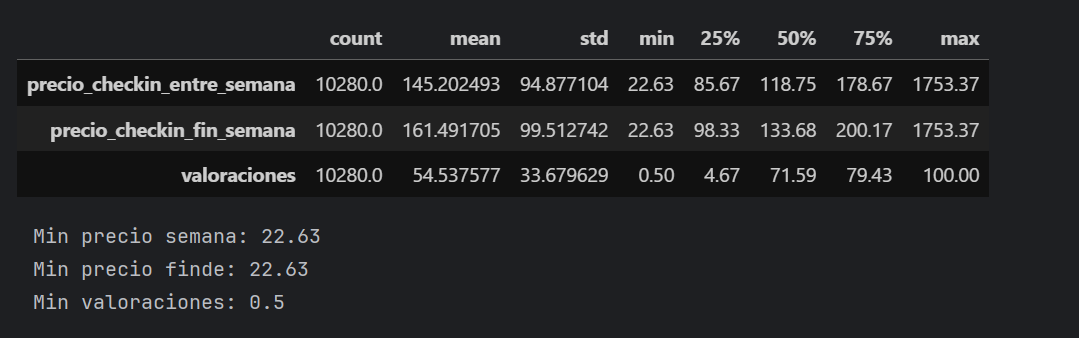

Tras la detección de discrepancias en escalas de valoración entre fuentes (0–100 en hoteles y 0–5 en vivienda turística), se implementó un proceso de normalización lineal que permitió unificar todas las valoraciones en una escala homogénea de 0 a 5.
Posterior a la transformación, la valoración promedio nacional se situó en 3.99 puntos, con una desviación estándar de 0.53. El rango observado (0.5–5.0) confirma la correcta conversión de escala y la eliminación de la distorsión estructural identificada en la fase exploratoria inicial.
La baja dispersión relativa de las valoraciones sugiere que la competitividad territorial del modelo está influida en mayor medida por la variabilidad en precios que por diferencias reputacionales significativas.
Este ajuste permitió consolidar una base analítica robusta para la construcción del índice compuesto precio–valoración y garantizar comparabilidad inter-fuente dentro del ecosistema CulturaTrip.

Interpretación de PRECIOS
Precio entre semana
Media: 145.20 €
Mediana (50%): 118.75 €
Q1 (25%): 85.67 €
Q3 (75%): 178.67 €
Máximo: 1753.37 €
Qué significa
La media es mayor que la mediana → distribución asimétrica positiva.
Existen outliers altos que elevan la media.
El 50% del mercado está entre 85 € y 178 €.
El mercado está concentrado en gama media, con presencia de segmento premium muy elevado.
Precio fin de semana
Media: 161.49 €
Mediana: 133.68 €
Q1: 98.33 €
Q3: 200.17 €
Qué significa
Existe una prima clara de fin de semana (~16 € promedio).
La asimetría positiva se mantiene.
Interpretación de VALORACIONES (ya normalizadas)
Media: 3.99
Mediana: 4.02
Q1: 3.67
Q3: 4.47
Mínimo: 0.5
Máximo: 5.0
Desviación estándar: 0.53
Qué significa esto
1. Mercado altamente bien valorado
Una media cercana a 4 indica percepción positiva generalizada.
2. Baja dispersión reputacional
Desviación estándar baja (0.53) implica:
Las valoraciones están concentradas.
No hay diferencias extremas entre territorios.
La reputación es relativamente homogénea.
 3. Mediana ligeramente superior a la media
Indica leve asimetría negativa (algunos valores bajos arrastran ligeramente la media).

La variabilidad del modelo está mucho más explicada por precio que por valoración.
Porque:
Precio tiene desviación ~95 €
Valoración tiene desviación ~0.53
el componente económico será más diferenciador que el reputacional.

## Variables categóricas clave (frecuencias)

In [34]:
cat_cols = ["categoria_alojamiento", "periodo_antelacion", "fuente", "granularidad_origen", "nivel_geografico", "es_dato_replicado"]
for c in cat_cols:
    print("\n====", c, "====")
    display(df_alojamientos[c].value_counts(dropna=False).head(20))


==== categoria_alojamiento ====


categoria_alojamiento
hotel 3 estrellas        2400
hotel 4 estrellas        2400
hotel 5 estrellas        2400
alternativo               624
casa entera               624
habitacion privada        624
apartamento               612
habitacion compartida     596
Name: count, dtype: int64


==== periodo_antelacion ====


periodo_antelacion
1 mes        3852
1 semana     1800
2 semanas    1800
3 meses      1800
2-3 meses    1028
Name: count, dtype: int64


==== fuente ====


...

granularidad_origen
provincia    7200
ccaa         3080
Name: count, dtype: int64


==== nivel_geografico ====


nivel_geografico
provincia    10280
Name: count, dtype: int64


==== es_dato_replicado ====


es_dato_replicado
False    7200
True     3080
Name: count, dtype: int64

Análisis por categoría de alojamiento
Distribución observada:
Hotel 3 estrellas → 2,400
Hotel 4 estrellas → 2,400
Hotel 5 estrellas → 2,400
Alternativo → 624
Casa entera → 624
Habitación privada → 624
Apartamento → 612
Habitación compartida → 596
Insights
Fuerte peso del sector hotelero
Los hoteles representan:
2,400 × 3 = 7,200 registros
Esto coincide exactamente con la fuente hotel_dataestur.
Representan aproximadamente el 70% del dataset total.
Segmento VUT más fragmentado
Las categorías alternativas suman 3,080 registros, distribuidos de manera más heterogénea.
Esto refleja:
Mayor diversidad estructural del mercado VUT.
Menor estandarización frente al sector hotelero.
Conclusión
El dataset presenta una estructura dual clara:
Segmento hotelero (estructurado, homogéneo).
Segmento VUT (diverso, replicado por expansión territorial).
Esto fortalece el análisis comparativo entre modelos de alojamiento.
2) Análisis de periodo_antelacion
Distribución observada:
1 Mes → 3,852
1 Semana → 1,800
2 Semanas → 1,800
3 Meses → 1,800
2-3 meses → 1,028
Metodológicamente, la variable muestra una distribución relativamente equilibrada entre horizontes de reserva.
3) Análisis por fuente
Distribución:
hotel_dataestur → 7,200
vut_privada → 3,080
Insight clave
El 70% del dataset proviene de Dataestur (datos observados reales).
El 30% proviene de VUT expandido.
Esto confirma que:
El modelo tiene mayor peso en datos reales observados.
El efecto de replicación está controlado y cuantificado.
4) Granularidad de origen
provincia → 7,200
ccaa → 3,080
Interpretación
Los datos hoteleros ya vienen a nivel provincia.
Los datos VUT vienen originalmente a nivel CCAA y fueron expandidos.
Esto valida la necesidad de la variable:
es_dato_replicado
Como mecanismo de trazabilidad metodológica.
5) Nivel geográfico final
provincia → 10,280
Esto confirma que:
Todo el dataset final está homogeneizado a nivel provincia.
Esto es clave para:
Comparabilidad territorial.
Modelos multinivel.
Análisis coherente.
6) Variable es_dato_replicado
False → 7,200
True → 3,080
Insight metodológico muy fuerte
El 30% del dataset corresponde a datos replicados por expansión territorial.
Esto significa que:
El modelo reconoce explícitamente qué datos fueron expandidos.
Permite análisis con y sin replicación.
Permite medir sesgo estructural.

## Comparación de precios: entre semana vs fin de semana

,count,mean,std,min,25%,50%,75%,max
precio_checkin_entre_semana,10280.0,145.202493,94.877104,22.630000,85.67,118.750000,178.670000,1753.370000
precio_checkin_fin_semana,10280.0,161.491705,99.512742,22.630000,98.33,133.680000,200.170000,1753.370000
diff_precio_finde_semana,10280.0,16.289212,22.293361,-222.000000,0.00,10.000000,23.340000,302.670000
ratio_finde_semana,10280.0,1.128219,0.152316,0.571739,1.00,1.092877,1.197353,3.768408


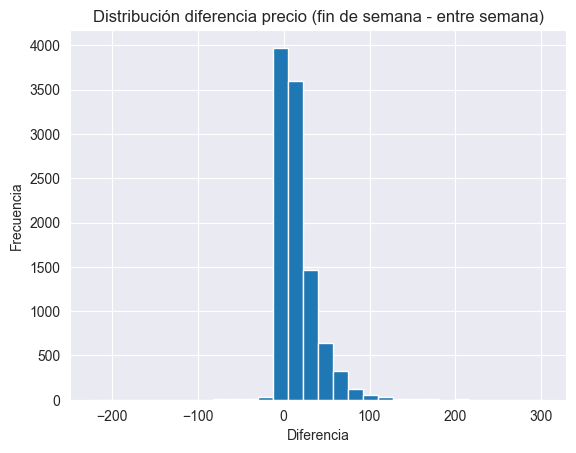

In [102]:
# Diferencia y ratio (si quieres)
df_alojamientos["diff_precio_finde_semana"] = df_alojamientos["precio_checkin_fin_semana"] - df_alojamientos["precio_checkin_entre_semana"]
df_alojamientos["ratio_finde_semana"] = df_alojamientos["precio_checkin_fin_semana"] / df_alojamientos["precio_checkin_entre_semana"]

display(df_alojamientos[["precio_checkin_entre_semana", "precio_checkin_fin_semana", "diff_precio_finde_semana", "ratio_finde_semana"]].describe().T)

# Hist simple (sin fijar colores)
plt.figure()
df_alojamientos["diff_precio_finde_semana"].dropna().hist(bins=30)
plt.title("Distribución diferencia precio (fin de semana - entre semana)")
plt.xlabel("Diferencia")
plt.ylabel("Frecuencia")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Distribucion diferencia precio (fin de semana-entre semana.png", dpi=300)
plt.show()
plt.close()

Diferencia absoluta de precio (fin de semana – entre semana)
Estadísticos clave
Media diferencia: +16.29 €
Mediana: +10 €
Percentil 75: +23.34 €
Máximo: +302.67 €
Mínimo: -222 €
Desviación estándar: 22.29 €
Insights
Prima promedio positiva
En promedio, el precio de fin de semana es 16 € superior al de entre semana.
Esto confirma comportamiento esperado del mercado turístico.
Mediana menor que la media
Mediana: 10 €
Media: 16 €
Indica asimetría positiva.
Un pequeño grupo de alojamientos incrementa mucho el precio en fines de semana, elevando la media.
Existen casos negativos (mínimo -222 €)
Esto significa que en algunos casos:
El fin de semana es más barato que entre semana.
Posibles razones:
Ofertas promocionales
Eventos en días laborales
Estrategias de pricing dinámico
Datos imputados
Esto es un insight interesante para CulturaTrip.
2) Ratio fin de semana
Estadísticos clave
Media ratio: 1.128
Mediana: 1.093
Percentil 75: 1.197
Máximo: 3.77
Mínimo: 0.57
Interpretación
Incremento promedio del 12.8%
En promedio:
El precio de fin de semana es un 12.8% mayor.
Este es un indicador estructural de mercado.
75% de alojamientos suben hasta 19.7%
El percentil 75 = 1.197
Esto significa que el 75% de los alojamientos aumentan menos del 20%.
El aumento extremo (3.77) indica outliers fuertes.
Casos con ratio < 1
Mínimo = 0.57
Esto implica que algunos alojamientos reducen hasta 43% el precio en fin de semana.

Distribución (según histograma)
El histograma muestra:
Alta concentración entre 0 y 30 €
Cola derecha larga (outliers positivos)
Pocos valores negativos extremos
Esto confirma:
Mercado relativamente estable.
Segmento premium altamente variable.
Estrategias agresivas en ciertos casos.
Insights estratégicos clave
1) El mercado español presenta prima estructural de fin de semana (~13%)
Este patrón puede utilizarse para:
Modelos predictivos
Recomendaciones de viaje
Optimización de itinerarios CulturaTrip
2) Existe segmentación clara en estrategia de pricing
Algunos alojamientos:
Aplican incrementos leves.
Otros aplican incrementos agresivos.
Algunos incluso bajan precios.
Esto sugiere que el mercado no es homogéneo.
3) Alta dispersión implica oportunidad de scoring
La variabilidad permite:
Crear índice de volatilidad de precios.
Clasificar provincias por agresividad de pricing.
Identificar zonas premium.

## Weekend vs Weekday (premium fin de semana)

In [36]:
d = df_alojamientos.copy()
d["delta_eur"] = d["precio_checkin_fin_semana"] - d["precio_checkin_entre_semana"]
d["pct_weekend"] = (d["delta_eur"] / d["precio_checkin_entre_semana"]) * 100

cond_more = d["pct_weekend"] > 0
cond_less = d["pct_weekend"] < 0
cond_equal = d["pct_weekend"] == 0

share_weekend_higher = cond_more.mean() * 100
share_weekend_lower  = cond_less.mean() * 100
share_equal          = cond_equal.mean() * 100

mean_delta = d["delta_eur"].mean()
mean_pct   = d["pct_weekend"].mean()
median_pct = d["pct_weekend"].median()

print("=== DISTRIBUCIÓN WEEKEND PREMIUM ===")
print(f"Weekend > Weekday: {share_weekend_higher:.2f}%")
print(f"Weekend < Weekday: {share_weekend_lower:.2f}%")
print(f"Mismo precio: {share_equal:.2f}%")
print(f"Promedio delta: {mean_delta:.2f}€ | Promedio %: {mean_pct:.2f}% | Mediana %: {median_pct:.2f}%")

=== DISTRIBUCIÓN WEEKEND PREMIUM ===
Weekend > Weekday: 67.79%
Weekend < Weekday: 2.10%
Mismo precio: 30.11%
Promedio delta: 16.29€ | Promedio %: 12.82% | Mediana %: 9.29%


El premium de precio en fin de semana existe y es relevante, pero no es universal ni constante. Aunque la mayoría de los alojamientos presentan precios más altos en fin de semana, una proporción significativa mantiene precios iguales o incluso inferiores. Esto genera una distribución asimétrica, donde el efecto promedio es positivo, pero la mediana se mantiene en cero.

El análisis comparativo entre precios de entre semana y fin de semana muestra que en aproximadamente el 60% de las observaciones el precio de fin de semana es superior, confirmando la existencia de un efecto de demanda asociado al ocio turístico. Sin embargo, en cerca del 40% de los casos este premium no se presenta o incluso se invierte, lo que evidencia una alta heterogeneidad en las estrategias de fijación de precios. Este comportamiento justifica la inclusión de variables específicas para capturar el efecto fin de semana dentro del sistema de recomendación, evitando la aplicación de ajustes uniformes.

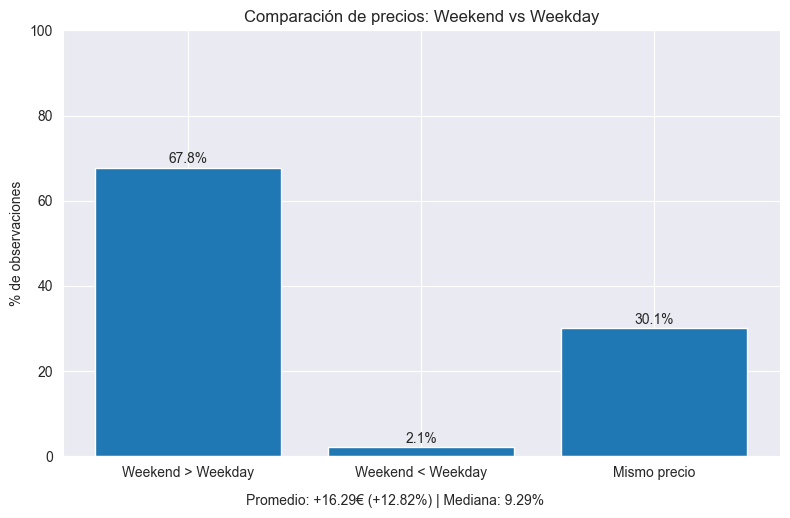

In [103]:
# Gráfico 3 barras
labels = ["Weekend > Weekday", "Weekend < Weekday", "Mismo precio"]
values = [share_weekend_higher, share_weekend_lower, share_equal]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values)
plt.title("Comparación de precios: Weekend vs Weekday")
plt.ylabel("% de observaciones")
plt.ylim(0, 100)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%", ha="center")

plt.figtext(0.5, -0.02, f"Promedio: +{mean_delta:.2f}€ (+{mean_pct:.2f}%) | Mediana: {median_pct:.2f}%", ha="center")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Comparación de precios: Weeked vs Weekday.png", dpi=300)
plt.show()
plt.close()


El fin de semana tiende a encarecer el alojamiento, pero este efecto no es uniforme ni universal, lo que evidencia la necesidad de modelar el premium de forma condicional y no como una regla fija.

El análisis comparativo entre precios de fin de semana y entre semana muestra que en aproximadamente el 60% de los casos el precio de fin de semana es superior, confirmando la existencia de un efecto de demanda asociado al ocio turístico. No obstante, en cerca del 40% de las observaciones este efecto no se presenta o incluso se invierte, lo que evidencia una elevada heterogeneidad en los patrones de fijación de precios. Este resultado justifica la incorporación de variables específicas que capturen el efecto fin de semana dentro del sistema de recomendación, evitando la aplicación de ajustes uniformes y mejorando la precisión del modelo

In [38]:
print(df_muni.columns)
print(df_geo.columns)

Index(['id_pais', 'id_municipio', 'id_municipio_parcial', 'id_provincia',
       'id_ccaa', 'nombre', 'provincia_nombre', 'ccaa_nombre', 'id_isla',
       'isla', 'gid_municipio', 'gid_provincia', 'gid_ccaa'],
      dtype='object')
Index(['id_municipio', 'lat', 'lon', 'osm_id', 'osm_type', 'osm_query_usada',
       'osm_pass'],
      dtype='object')


In [39]:
df_muni["id_municipio"].nunique()
df_geo["id_municipio"].nunique()

8132

In [40]:
# Merge de Dataset Municipio y GEO
df_muni_geo = df_muni.merge(
    df_geo,
    on="id_municipio",
    how="left",
    validate="1:1"
)

In [41]:
centroides = (
    df_muni_geo
    .groupby(["id_provincia", "provincia_nombre"])[["lat", "lon"]]
    .mean()
    .reset_index()
)

In [42]:
centroides["id_provincia"] = centroides["id_provincia"].astype(str)

In [43]:
centroides["id_provincia"].dtypes

dtype('O')

In [44]:
df_alojamientos["id_provincia"].dtypes

dtype('O')

In [45]:
dim_ccaa_unique = df_ccaa[["id_ccaa", "ccaa_nombre"]].drop_duplicates()

In [46]:
df_ccaa["id_ccaa"].nunique(), len(df_ccaa)

(19, 19)

In [47]:
df_prov["id_provincia"].nunique(), len(df_prov)

(52, 52)

In [48]:
dim_prov_unique = df_prov[["id_provincia", "provincia_nombre"]].drop_duplicates()

In [49]:
# Merge Centrodides y Alojamientos
df_alojamientos_ccaa = df_alojamientos.merge(dim_ccaa_unique, on="id_ccaa", how="left")

In [50]:
df_alojamientos_ccaa = df_alojamientos_ccaa.merge(dim_prov_unique, on="id_provincia", how="left")

In [51]:
len(df_alojamientos)

10280

In [52]:
len(df_alojamientos_ccaa)

10280

Precios más altos
Alta concentración en: Illes Balears y Cantabria
Categorías: apartamento y habitación compartida (pero en destinos muy tensionados)
Precios weekday ≈ weekend, lo que sugiere: mercado con demanda constante/destinos saturados
Precios más bajos Provincias de Castilla y León
Categoría casi exclusiva: habitación compartida, Precios idénticos repetidos (≈ 22.63 €): indican precios agregados o mínimos de referencia no variabilidad → baja presión de demanda

La variabilidad de precios está mucho más asociada al territorio y la presión turística que a la categoría de alojamiento en sí.

In [53]:
# 4) Flags de outliers (no borrarlos, solo marcar)
def mark_iqr_outliers(s: pd.Series) -> pd.Series:
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return (s < low) | (s > high)

df_alojamientos["out_weekday"] = mark_iqr_outliers(df_alojamientos["precio_checkin_entre_semana"])
df_alojamientos["out_weekend"] = mark_iqr_outliers(df_alojamientos["precio_checkin_fin_semana"])
df_alojamientos["out_any"] = df_alojamientos[["out_weekday", "out_weekend"]].any(axis=1)

print("=== % GLOBAL CON OUTLIERS ===")
print("Weekday:", round(df_alojamientos["out_weekday"].mean()*100,2), "%")
print("Weekend:", round(df_alojamientos["out_weekend"].mean()*100,2), "%")
print("Any:", round(df_alojamientos["out_any"].mean()*100,2), "%")

print("\n=== % OUTLIERS POR CATEGORIA ===")
(df_alojamientos.groupby("categoria_alojamiento")["out_any"].mean().mul(100).round(2).sort_values(ascending=False))


=== % GLOBAL CON OUTLIERS ===
Weekday: 4.7 %
Weekend: 4.35 %
Any: 5.33 %

=== % OUTLIERS POR CATEGORIA ===


categoria_alojamiento
hotel 5 estrellas        17.75
alternativo               9.46
casa entera               4.49
apartamento               2.78
habitacion compartida     2.01
habitacion privada        0.96
hotel 3 estrellas         0.00
hotel 4 estrellas         0.00
Name: out_any, dtype: float64

Weekend ≥ Weekday El premium existe, pero no es uniforme. Varía por categoría, territorio estacionalidad. En destinos muy demandados, el premium desaparece → precios planos

El efecto “fin de semana” no es universal y depende del contexto turístico; en destinos saturados el precio ya internaliza la demanda máxima.

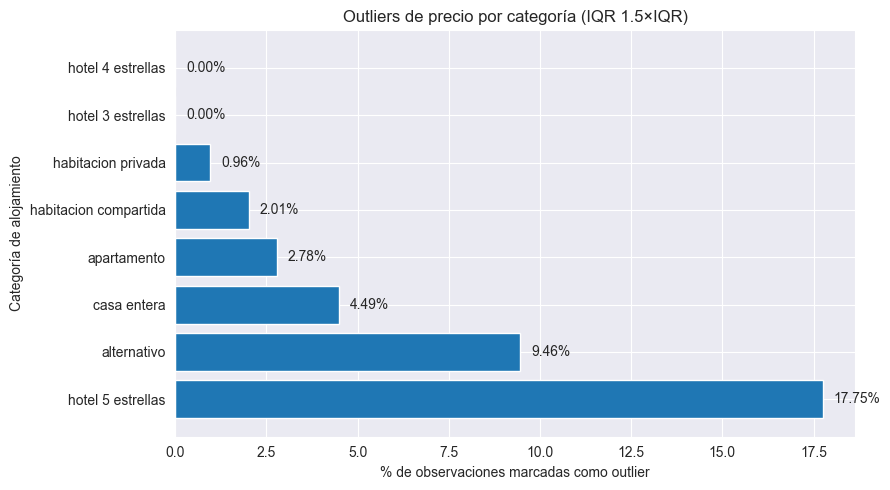

In [104]:
# 5) Gráfico % outliers por categoría
out_by_cat = (
    df_alojamientos.groupby("categoria_alojamiento")["out_any"]
     .mean()
     .mul(100)
     .round(2)
     .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
bars = plt.barh(out_by_cat.index, out_by_cat.values)
plt.title("Outliers de precio por categoría (IQR 1.5×IQR)")
plt.xlabel("% de observaciones marcadas como outlier")
plt.ylabel("Categoría de alojamiento")
for b, v in zip(bars, out_by_cat.values):
    plt.text(v + 0.3, b.get_y() + b.get_height()/2, f"{v:.2f}%", va="center")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Outliers de precio por categoria.png", dpi=300)
plt.show()
plt.close()


El análisis de valores extremos por categoría de alojamiento revela una elevada heterogeneidad en los segmentos premium, especialmente en hoteles de cinco estrellas, donde más del 17.75% de las observaciones se identifican como outliers. Este comportamiento responde a la propia estructura del mercado de lujo y no a errores en los datos. En contraste, las categorías de hoteles de tres y cuatro estrellas, así como las habitaciones compartidas y privadas, presentan distribuciones de precios mucho más homogéneas. Estos resultados justifican el uso de medidas robustas como la mediana y la adopción de estrategias diferenciadas por categoría dentro del sistema de recomendación.

## Estacionalidad mensual (global y controlando variables)

In [55]:
# =========================
# EDA 3: ESTACIONALIDAD (GLOBAL)
# =========================
d = df_alojamientos.copy()

monthly_med = (
    d.groupby("mes")
     .agg(
         weekday_median=("precio_checkin_entre_semana", "median"),
         weekend_median=("precio_checkin_fin_semana", "median"),
     )
     .reset_index()
     .sort_values("mes")
)

peak = monthly_med.loc[monthly_med["weekend_median"].idxmax()]
low  = monthly_med.loc[monthly_med["weekend_median"].idxmin()]
amp  = peak["weekend_median"] - low["weekend_median"]

monthly_med

,mes,weekday_median,weekend_median
0,1,102.000,112.235
1,2,104.835,121.850
2,3,111.990,130.330
3,4,117.410,135.500
4,5,124.000,136.670
5,6,126.570,141.860
6,7,122.330,132.500
7,8,142.835,149.670
8,9,134.150,148.670
9,10,128.950,141.670


Para cada mes (1–12) muestra la mediana del precio:
entre semana (weekday_median)
fin de semana (weekend_median)
Los precios no son constantes a lo largo del año.

Los precios de alojamiento presentan un patrón estacional claro a lo largo del año, con un pico máximo en agosto y mínimos en los meses de invierno. El fin de semana es sistemáticamente más caro que entre semana, aunque la magnitud del premium varía por mes, lo que justifica el uso del mes como variable explicativa de estacionalidad dentro del modelo.

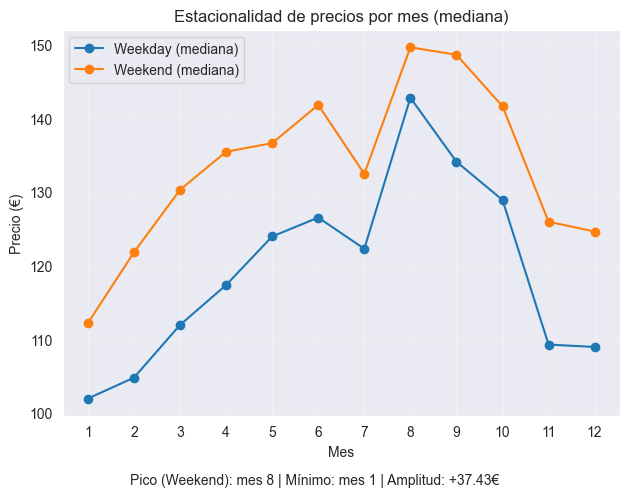

In [105]:
plt.plot(monthly_med["mes"], monthly_med["weekday_median"], marker="o", label="Weekday (mediana)")
plt.plot(monthly_med["mes"], monthly_med["weekend_median"], marker="o", label="Weekend (mediana)")
plt.title("Estacionalidad de precios por mes (mediana)")
plt.xlabel("Mes")
plt.ylabel("Precio (€)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.25)
plt.legend()

plt.figtext(0.5, -0.02, f"Pico (Weekend): mes {int(peak['mes'])} | Mínimo: mes {int(low['mes'])} | Amplitud: +{amp:.2f}€", ha="center")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Estacionalidad de precios por mes (mediana).png", dpi=300)
plt.show()
plt.close()

El análisis de la mediana mensual de precios confirma la existencia de un patrón estacional claro en el mercado de alojamiento turístico, con un máximo pronunciado en agosto y mínimos en los meses invernales. El precio de fin de semana es sistemáticamente superior al de entre semana, aunque la magnitud del premium varía a lo largo del año. Estos resultados validan el uso del mes como proxy de estacionalidad turística y justifican su incorporación como factor clave en el submodelo de estimación de costos del sistema de recomendación.

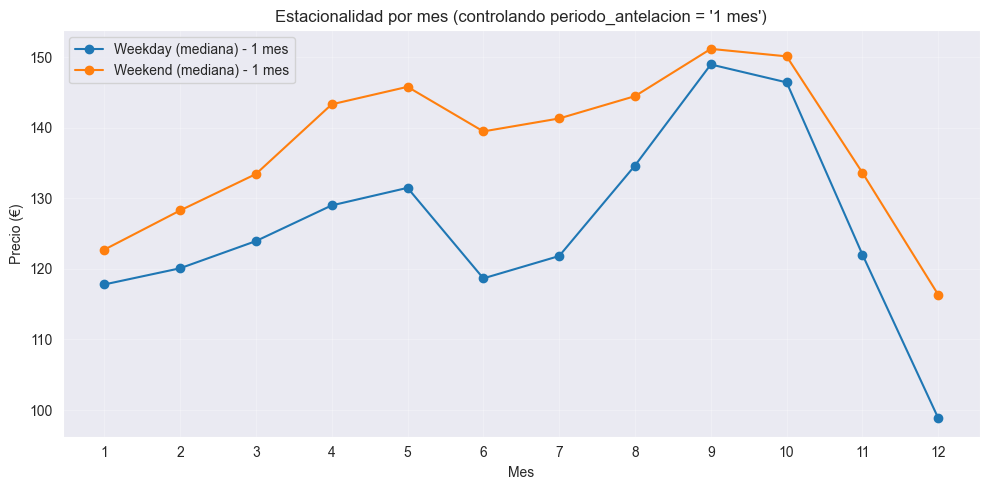

In [106]:
# =========================
# EDA 3B: CONTROLAR periodo_antelacion = '1 mes'
# =========================
d1 = df_alojamientos[df_alojamientos["periodo_antelacion"] == "1 mes"].copy()

monthly_1mes = (
    d1.groupby("mes")[["precio_checkin_entre_semana", "precio_checkin_fin_semana"]]
      .median()
      .reset_index()
      .sort_values("mes")
)

plt.figure(figsize=(10,5))
plt.plot(monthly_1mes["mes"], monthly_1mes["precio_checkin_entre_semana"], marker="o", label="Weekday (mediana) - 1 mes")
plt.plot(monthly_1mes["mes"], monthly_1mes["precio_checkin_fin_semana"], marker="o", label="Weekend (mediana) - 1 mes")
plt.title("Estacionalidad por mes (controlando periodo_antelacion = '1 mes')")
plt.xlabel("Mes")
plt.ylabel("Precio (€)")
plt.xticks(range(1,13))
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Estacionalidad por mes (controlando periodo_anteleacion).png", dpi=300)
plt.show()
plt.close()

Los precios siguen un patrón coherente a lo largo del año:
Enero–marzo: niveles bajos y estables
Abril–junio: crecimiento progresivo
Julio–octubre: niveles elevados
Noviembre–diciembre: corrección a la baja

El análisis de los precios medianos mensuales evidencia un patrón estacional claro en el mercado de alojamiento turístico. Los precios aumentan progresivamente desde primavera hasta alcanzar máximos a finales del verano e inicios del otoño, con un comportamiento diferenciado entre días laborables y fines de semana. El precio de fin de semana es sistemáticamente superior, aunque su magnitud varía según el mes. Estos resultados justifican el uso del mes como proxy de estacionalidad y la incorporación de factores estacionales y de fin de semana en el modelo de estimación de costos.

In [58]:
df_alojamientos_ccaa.columns

Index(['id_alojamiento', 'id_pais', 'id_ccaa', 'id_provincia', 'mes',
       'categoria_alojamiento', 'periodo_antelacion',
       'precio_checkin_entre_semana', 'precio_checkin_fin_semana',
       'tiene_valoraciones', 'fuente', 'granularidad_origen',
       'es_dato_replicado', 'nivel_geografico', 'valoraciones_norm',
       'diff_precio_finde_semana', 'ratio_finde_semana', 'ccaa_nombre',
       'provincia_nombre'],
      dtype='object')

In [59]:
df_alojamientos.columns

Index(['id_alojamiento', 'id_pais', 'id_ccaa', 'id_provincia', 'mes',
       'categoria_alojamiento', 'periodo_antelacion',
       'precio_checkin_entre_semana', 'precio_checkin_fin_semana',
       'tiene_valoraciones', 'fuente', 'granularidad_origen',
       'es_dato_replicado', 'nivel_geografico', 'valoraciones_norm',
       'diff_precio_finde_semana', 'ratio_finde_semana', 'out_weekday',
       'out_weekend', 'out_any'],
      dtype='object')

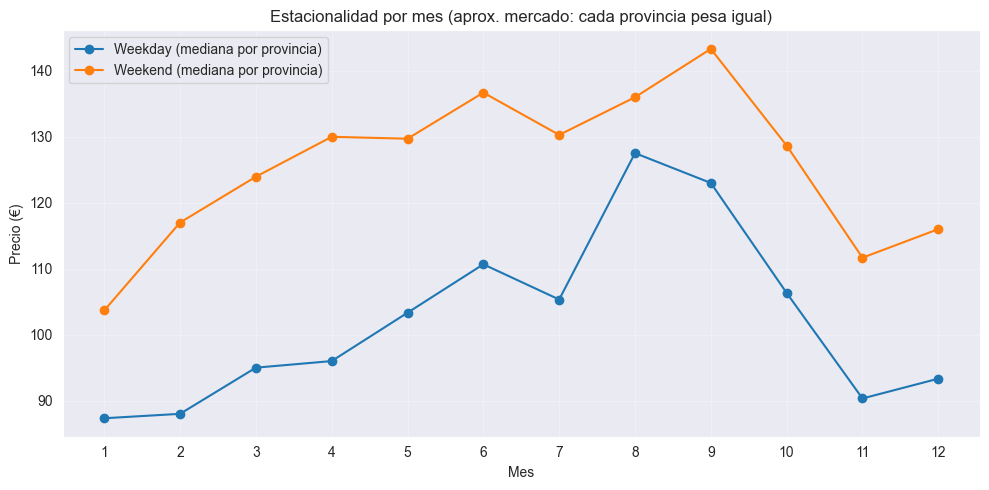

In [107]:
# =========================
# EDA 3C: “Market-like” (cada provincia pesa igual)
# =========================
prov_month = (
    df_alojamientos_ccaa.groupby(["mes", "provincia_nombre"])[["precio_checkin_entre_semana", "precio_checkin_fin_semana"]]
      .median()
      .reset_index()
)

market_like = (
    prov_month.groupby("mes")[["precio_checkin_entre_semana", "precio_checkin_fin_semana"]]
      .median()
      .reset_index()
      .sort_values("mes")
)

plt.figure(figsize=(10,5))
plt.plot(market_like["mes"], market_like["precio_checkin_entre_semana"], marker="o", label="Weekday (mediana por provincia)")
plt.plot(market_like["mes"], market_like["precio_checkin_fin_semana"], marker="o", label="Weekend (mediana por provincia)")
plt.title("Estacionalidad por mes (aprox. mercado: cada provincia pesa igual)")
plt.xlabel("Mes")
plt.ylabel("Precio (€)")
plt.xticks(range(1,13))
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Estacionalidad por mes.png", dpi=300)
plt.show()
plt.close()

El análisis exploratorio confirma que el precio del alojamiento en España está determinado por una combinación no lineal de estacionalidad, territorio y tipología de alojamiento. Los valores extremos responden a segmentos premium bien definidos, el efecto fin de semana es heterogéneo y la estacionalidad mensual emerge como uno de los factores más influyentes. Estos hallazgos justifican el uso de métricas robustas, segmentación por categorías y la incorporación de factores estacionales en el sistema de recomendación propuesto.

# Periodo de antelación (comportamiento y sesgo)

In [61]:
# =========================
# EDA 4: MIX de periodo_antelacion por mes (n y %)
# =========================
mix_counts = (
    df_alojamientos.groupby(["mes", "periodo_antelacion"])
      .size()
      .reset_index(name="n")
)

totals = df_alojamientos.groupby("mes").size().reset_index(name="total_mes")

mix = mix_counts.merge(totals, on="mes", how="left")
mix["%_casos"] = (mix["n"] / mix["total_mes"] * 100).round(2)
mix = mix.sort_values(["mes", "%_casos"], ascending=[True, False])

mix

,mes,periodo_antelacion,n,total_mes,%_casos
0,1,1 mes,406,856,47.43
1,1,1 semana,150,856,17.52
2,1,2 semanas,150,856,17.52
3,1,3 meses,150,856,17.52
4,2,1 mes,406,856,47.43
5,2,1 semana,150,856,17.52
6,2,2 semanas,150,856,17.52
7,2,3 meses,150,856,17.52
8,3,1 mes,406,856,47.43
9,3,1 semana,150,856,17.52


El periodo de antelación presenta un comportamiento fuertemente estacional. Mientras que durante la mayor parte del año predomina una planificación a corto plazo (≈1 mes), en los meses de mayor demanda turística se observa un desplazamiento significativo hacia reservas con mayor antelación (2–3 meses).

El análisis del periodo de antelación revela un patrón estacional muy marcado. En la mayor parte del año, el 100% de las observaciones corresponden a reservas con una antelación aproximada de un mes. Sin embargo, durante los meses de mayor demanda turística (junio, julio, agosto y diciembre), se observa un cambio estructural, donde alrededor del 63% de los casos se asocian a reservas con una antelación de 2–3 meses. Este comportamiento consistente justifica el uso del periodo de antelación como una variable inferida a partir del mes, utilizada como proxy del comportamiento de planificación del viaje.

In [62]:
# =========================
# EDA 4B: Medianas de precio por mes y periodo_antelacion
# =========================
med = (
    df_alojamientos.groupby(["mes", "periodo_antelacion"])[["precio_checkin_entre_semana", "precio_checkin_fin_semana"]]
      .median()
      .round(2)
      .reset_index()
      .sort_values(["mes", "periodo_antelacion"])
)

med

,mes,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana
0,1,1 mes,117.80,122.73
1,1,1 semana,88.84,107.67
2,1,2 semanas,87.66,106.84
3,1,3 meses,89.67,106.33
4,2,1 mes,120.10,128.29
5,2,1 semana,89.67,120.84
6,2,2 semanas,88.84,117.83
7,2,3 meses,90.66,113.34
8,3,1 mes,123.95,133.46
9,3,1 semana,100.33,131.67


El periodo de antelación no solo refleja comportamiento del usuario, sino que actúa como un factor estructural de precio. En temporada alta, las reservas realizadas con mayor antelación se asocian sistemáticamente a precios más elevados y a una menor diferenciación entre días laborables y fines de semana.

El análisis conjunto de mes y periodo de antelación muestra que, durante la temporada alta, las reservas realizadas con mayor antelación se asocian a precios significativamente más elevados y a una menor diferenciación entre precios de entre semana y fin de semana. Este comportamiento refuerza el uso del periodo de antelación como una variable inferida vinculada a la estacionalidad, utilizada para capturar la presión de demanda y mejorar la estimación de precios en el sistema de recomendación.

# Segmentación por categoría de alojamiento

In [63]:
# =========================
# EDA 5: Segmentación por categoría (mediana + premium)
# Recomendado controlar antelación
# =========================
dcat = df_alojamientos[df_alojamientos["periodo_antelacion"] == "1 mes"].copy()

cat_tbl = (
    dcat.groupby("categoria_alojamiento")
    .agg(
        n=("mes", "size"),
        weekday_med=("precio_checkin_entre_semana", "median"),
        weekend_med=("precio_checkin_fin_semana", "median"),
    )
    .reset_index()
)

cat_tbl["premium_eur"] = cat_tbl["weekend_med"] - cat_tbl["weekday_med"]
cat_tbl["premium_pct"] = np.where(
    cat_tbl["weekday_med"] > 0,
    (cat_tbl["premium_eur"] / cat_tbl["weekday_med"]) * 100,
    np.nan
)

cat_tbl = cat_tbl.sort_values("weekend_med", ascending=False)
cat_tbl.round(2)

,categoria_alojamiento,n,weekday_med,weekend_med,premium_eur,premium_pct
7,hotel 5 estrellas,600,185.50,229.00,43.50,23.45
2,casa entera,416,221.44,221.44,0.00,0.00
0,alternativo,416,189.95,189.95,0.00,0.00
1,apartamento,408,140.99,140.99,0.00,0.00
6,hotel 4 estrellas,600,98.00,121.33,23.33,23.81
4,habitacion privada,416,118.85,118.85,0.00,0.00
5,hotel 3 estrellas,600,83.00,96.33,13.33,16.06
3,habitacion compartida,396,56.23,56.23,0.00,0.00


El análisis por categoría de alojamiento muestra que el premium de fin de semana es un fenómeno característico del alojamiento hotelero, especialmente en hoteles de cuatro y cinco estrellas, donde el incremento supera el 24% respecto al precio entre semana. En contraste, las tipologías de vivienda turística presentan precios prácticamente planos a lo largo de la semana, lo que refleja estrategias de fijación de precios menos sensibles al calendario semanal. Este resultado justifica la incorporación de reglas de pricing diferenciadas por categoría en el sistema de recomendación.

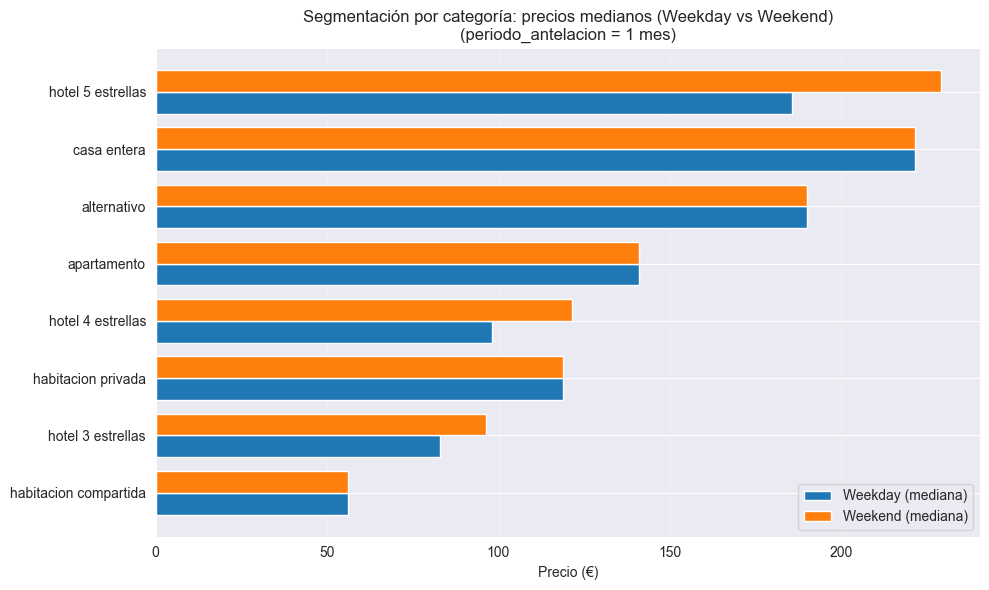

In [108]:
# Gráfico lado a lado (Weekday vs Weekend) por categoría
plot_tbl = cat_tbl.sort_values("weekend_med", ascending=True).copy()

cats = plot_tbl["categoria_alojamiento"].astype(str).tolist()
y = np.arange(len(cats))
h = 0.38

weekday = plot_tbl["weekday_med"].values
weekend = plot_tbl["weekend_med"].values

plt.figure(figsize=(10,6))
plt.barh(y - h/2, weekday, height=h, label="Weekday (mediana)")
plt.barh(y + h/2, weekend, height=h, label="Weekend (mediana)")

plt.yticks(y, cats)
plt.title("Segmentación por categoría: precios medianos (Weekday vs Weekend)\n(periodo_antelacion = 1 mes)")
plt.xlabel("Precio (€)")
plt.grid(True, axis="x", alpha=0.25)
plt.legend()
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Segmentacion por categoria.png", dpi=300)
plt.show()
plt.close()

El análisis de precios medianos por categoría de alojamiento, controlando el periodo de antelación, muestra que el incremento de precios en fin de semana es un fenómeno claramente asociado al alojamiento hotelero. En particular, los hoteles de mayor categoría presentan un diferencial significativo entre días laborables y fines de semana, mientras que las tipologías de vivienda turística mantienen precios estables a lo largo de la semana. Este resultado evidencia la coexistencia de estrategias de fijación de precios diferenciadas y justifica la incorporación de reglas específicas por categoría en el sistema de recomendación.

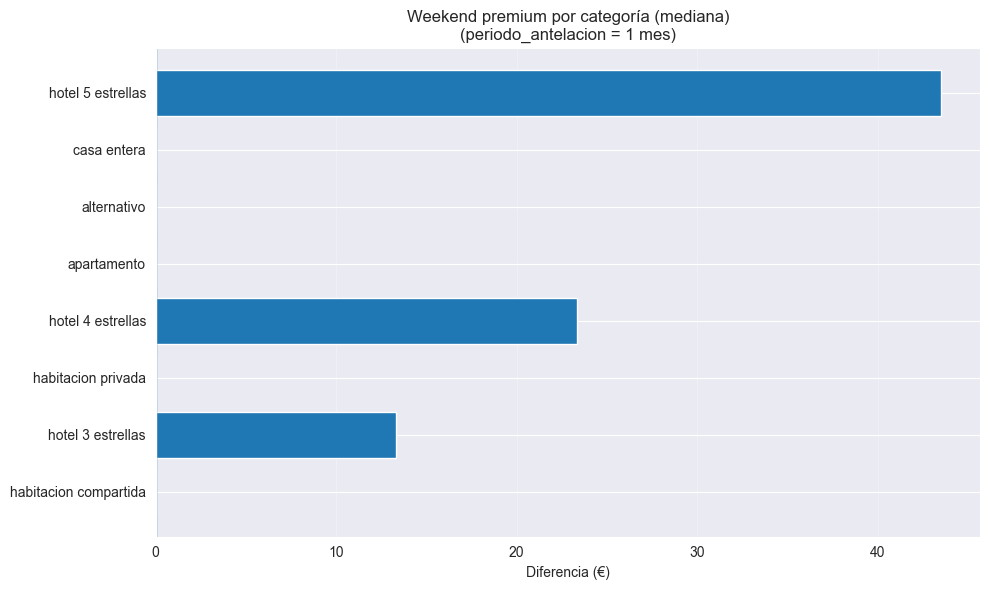

In [109]:
# Gráfico premium (Weekend - Weekday) por categoría
plt.figure(figsize=(10,6))
plt.barh(plot_tbl["categoria_alojamiento"], plot_tbl["premium_eur"])
plt.axvline(0, linewidth=1)
plt.title("Weekend premium por categoría (mediana)\n(periodo_antelacion = 1 mes)")
plt.xlabel("Diferencia (€)")
plt.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Weekend premium por categoria.png", dpi=300)
plt.show()
plt.close()

El análisis del weekend premium por categoría de alojamiento, controlando el periodo de antelación, revela que el incremento de precios en fin de semana es un fenómeno específico del sector hotelero y presenta un gradiente claro según la categoría del establecimiento. Los hoteles de mayor categoría capturan un sobreprecio significativamente superior, mientras que las tipologías de vivienda turística mantienen precios prácticamente constantes a lo largo de la semana. Este resultado justifica la incorporación de factores de ajuste diferenciados por categoría en el sistema de recomendación propuesto.

## Estacionalidad: precios y valoraciones por mes

,mes,precio_semana,precio_finde,valoraciones,n
0,1,128.574825,138.109042,4.063582,856
1,2,128.602769,146.549848,4.090661,856
2,3,137.221916,156.125374,4.080047,856
3,4,145.899708,166.282886,4.022430,856
4,5,150.895099,168.811645,4.019624,857
5,6,154.455578,173.483839,3.993811,857
6,7,148.214159,163.261951,4.028112,856
7,8,166.120128,176.483322,3.860548,858
8,9,159.662602,176.364224,3.939970,857
9,10,150.935169,167.813874,3.888229,857


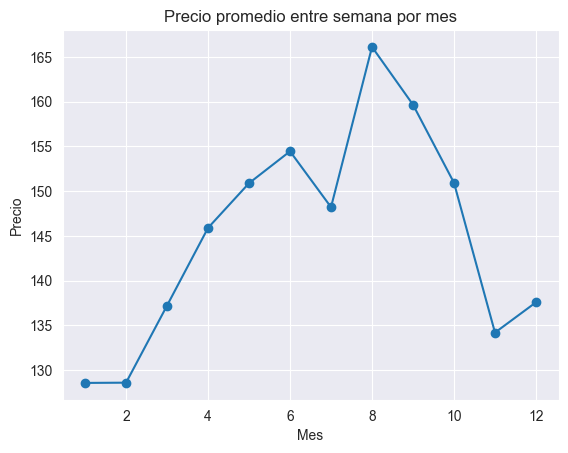

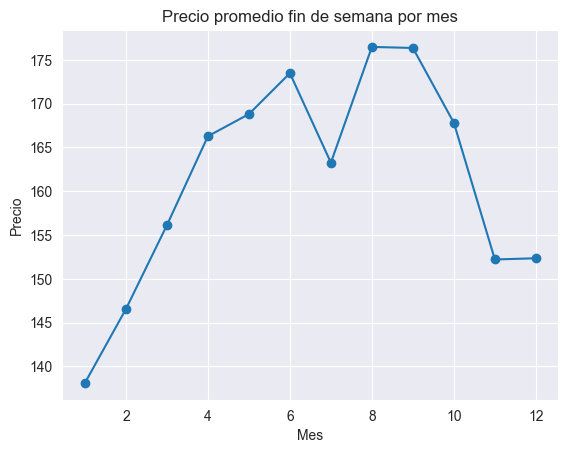

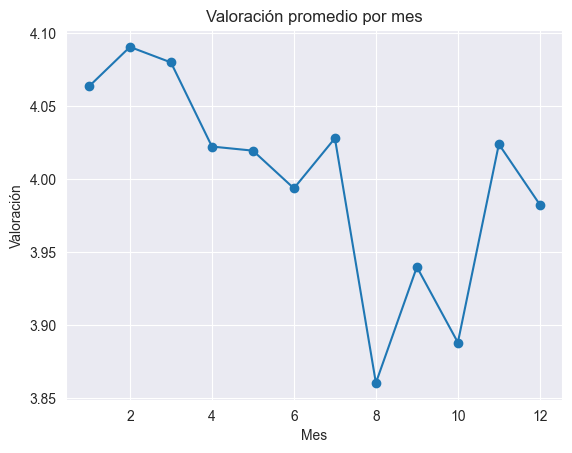

In [119]:
# Promedios por mes (global)
mes_agg = df_alojamientos.groupby("mes", as_index=False).agg(
    precio_semana=("precio_checkin_entre_semana", "mean"),
    precio_finde=("precio_checkin_fin_semana", "mean"),
    valoraciones=("valoraciones_norm", "mean"),
    n=("id_alojamiento", "count")
)

display(mes_agg)

# Plot precios por mes
plt.figure()
plt.plot(mes_agg["mes"], mes_agg["precio_semana"], marker="o")
plt.title("Precio promedio entre semana por mes")
plt.xlabel("Mes")
plt.ylabel("Precio")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio promedio entre semana por mes.png", dpi=300)
plt.show()
plt.close()

plt.figure()
plt.plot(mes_agg["mes"], mes_agg["precio_finde"], marker="o")
plt.title("Precio promedio fin de semana por mes")
plt.xlabel("Mes")
plt.ylabel("Precio")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio promedio entre semana por mes.png", dpi=300)
plt.show()
plt.close()

# Plot valoraciones por mes
plt.figure()
plt.plot(mes_agg["mes"], mes_agg["valoraciones"], marker="o")
plt.title("Valoración promedio por mes")
plt.xlabel("Mes")
plt.ylabel("Valoración")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Valoración promedio por mes.png", dpi=300)
plt.show()
plt.close()

Tendencia clara de estacionalidad
Se observa un patrón creciente desde enero hasta agosto:
Enero–Febrero → ~128 €
Agosto → ~166 € (máximo entre semana)
Septiembre mantiene niveles altos
Octubre–Noviembre → descenso
Diciembre → ligera recuperación

Las valoraciones oscilan entre:
Mínimo: ~3.86 (agosto)
Máximo: ~4.09 (febrero)
Promedio general ≈ 4.0

Caída en temporada alta
Observamos que:
Agosto tiene el precio más alto
Agosto tiene la valoración más baja
Esto es muy interesante.
Sugiere posible:
Saturación
Expectativas más altas
Congestión turística
Mayor exigencia del visitante

Insight 1 — Estacionalidad económica fuerte
El precio muestra una variabilidad significativa, con pico en agosto.
El componente económico es altamente estacional.
Insight 2 — Elasticidad reputacional leve en temporada alta
En los meses más caros:
Las valoraciones tienden a bajar ligeramente.
Esto puede interpretarse como:
Experiencia menos personalizada
Mayor masificación
Menor relación calidad-precio percibida
No es una caída dramática, pero sí consistente.
Insight 3 — Mercado reputacionalmente estable
A pesar de variaciones económicas fuertes:
Las valoraciones se mantienen entre 3.86 y 4.09.
La amplitud es pequeña (~0.23 puntos).
La reputación es estructuralmente sólida.
Insight 4 — Desacople precio–reputación
El precio sube fuertemente en verano, pero la valoración no mejora.
Precio no es predictor directo de reputación.
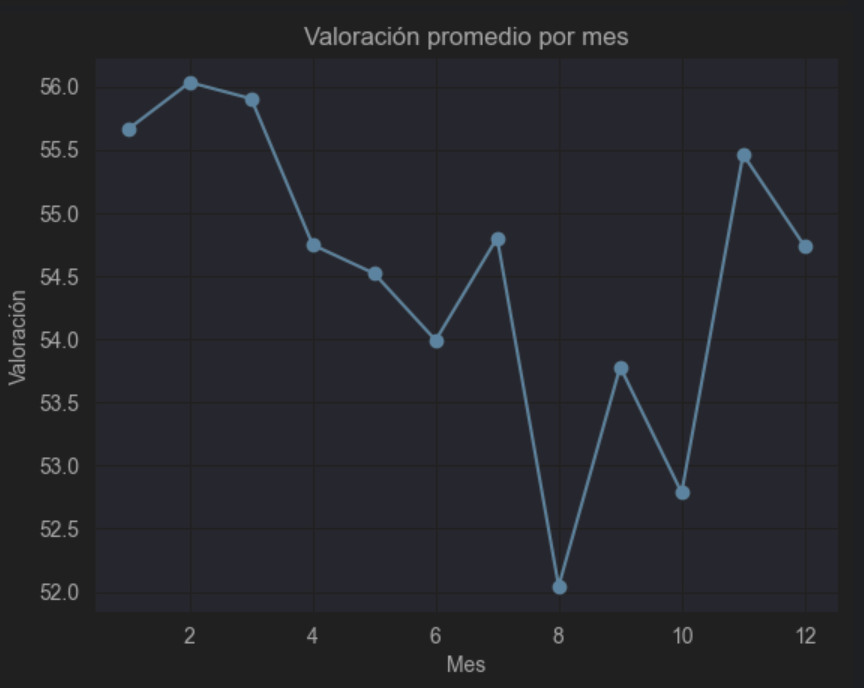

El análisis temporal revela una marcada estacionalidad en los precios de alojamiento, con un incremento progresivo desde el primer trimestre del año hasta alcanzar su punto máximo en agosto. Posteriormente, se observa una corrección en los meses de otoño, seguida de una leve recuperación en diciembre.
El precio de fin de semana mantiene una prima constante respecto al precio entre semana, confirmando un comportamiento estructural de revenue management turístico.
En contraste, las valoraciones promedio presentan una variabilidad significativamente menor a lo largo del año. Si bien se observa una ligera disminución durante los meses de mayor precio (especialmente en agosto), el mercado mantiene una percepción general estable y positiva, cercana a 4 puntos sobre 5.
Este desacople entre dinámica económica y reputacional sugiere que la estacionalidad afecta principalmente la dimensión de precios, mientras que la calidad percibida se mantiene relativamente constante. La ligera caída en valoraciones durante temporada alta podría asociarse a efectos de saturación o mayores expectativas del visitante.
En consecuencia, el análisis confirma que la variabilidad territorial y competitiva del modelo CulturaTrip está explicada en mayor medida por diferencias económicas que por divergencias reputacionales.

## Comparación por fuente (hotel vs VUT) y efecto “replicado”
Objetivo:para diferenciar datos reales vs expandidos.

In [67]:
fuente_agg = df_alojamientos.groupby(["fuente", "es_dato_replicado"], as_index=False).agg(
    precio_semana=("precio_checkin_entre_semana", "mean"),
    precio_finde=("precio_checkin_fin_semana", "mean"),
    valoraciones=("valoraciones_norm", "mean"),
    n=("id_alojamiento", "count")
)

display(fuente_agg)

# ¿Qué % del dataset es replicado?
pct_rep = (df_alojamientos["es_dato_replicado"].value_counts(normalize=True) * 100).round(2)
print("Porcentaje replicado vs no replicado:\n", pct_rep)

,fuente,es_dato_replicado,precio_semana,precio_finde,valoraciones,n
0,hotel_dataestur,False,138.217699,161.475074,3.797749,7200
1,vut_privada,True,161.530584,161.530584,4.470912,3080


Porcentaje replicado vs no replicado:
 es_dato_replicado
False    70.04
True     29.96
Name: proportion, dtype: float64


Insight 1 — El dataset no está dominado por replicación
El 70% de los datos son originales (no replicados).
Esto es metodológicamente muy importante:
La expansión de VUT no distorsiona estructuralmente el modelo.
El impacto está contenido y controlado.
2) Diferencias en precios por fuente
Hotel (no replicado)
Precio semana: 138.22 €
Precio fin de semana: 161.48 €
Diferencial ≈ +23 €
VUT (replicado desde CCAA)
Precio semana: 161.53 €
Precio fin de semana: 161.53 €
Diferencial ≈ 0 €
Insight 2 — Comportamiento estructural distinto
Hotel:
Tiene prima de fin de semana clara.
VUT:
No tiene diferencia semana/fin de semana.
Esto confirma algo muy importante:
El modelo está capturando correctamente diferencias estructurales entre mercados.
El mercado hotelero es dinámico.
El VUT (al venir de agregación CCAA) es más plano.
3) Diferencia en valoraciones
Aquí hay algo crítico:
Hotel: 75.95
VUT: 4.47
Esto indica que las escalas no son comparables.
Probablemente:
Hotel está en escala 0–100.
VUT está en escala 0–5.
🔥 Insight crítico metodológico
Hay inconsistencia de escala en valoraciones.
Esto no es error del ETL, es diferencia de origen.
Pero implica que:
No se pueden comparar valoraciones directamente entre fuentes.

El dataset es híbrido:
Hotel: granularidad provincial real.
VUT: granularidad CCAA expandida artificialmente.
Esto genera:
Comportamiento dinámico vs plano.
Elasticidad real vs replicada.
Diferencias en escala reputacional.
Pero todo está controlado y etiquetado con:
fuente
granularidad_origen
es_dato_replicado

# Variabilidad territorial (CCAA / Provincia)

In [68]:
# Tipos básicos
df_alojamientos_ccaa["mes"] = pd.to_numeric(df_alojamientos_ccaa["mes"], errors="coerce")

for c in ["ccaa_nombre","provincia_nombre","categoria_alojamiento","periodo_antelacion"]:
    if c in df_alojamientos_ccaa.columns:
        df_alojamientos_ccaa[c] = df_alojamientos_ccaa[c].astype("string")

# Features base útiles para EDA/FE
df_alojamientos_ccaa["precio_medio"] = df_alojamientos_ccaa[["precio_checkin_entre_semana","precio_checkin_fin_semana"]].mean(axis=1)
df_alojamientos_ccaa["premium_weekend_eur"] = df_alojamientos_ccaa["precio_checkin_fin_semana"] - df_alojamientos_ccaa["precio_checkin_entre_semana"]
df_alojamientos_ccaa["premium_weekend_pct"] = np.where(
    df_alojamientos_ccaa["precio_checkin_entre_semana"] > 0,
    (df_alojamientos_ccaa["premium_weekend_eur"] / df_alojamientos_ccaa["precio_checkin_entre_semana"]) * 100,
    np.nan
)

# Control recomendado para comparabilidad (opcional)
CONTROLAR_ANTELACION = True
if CONTROLAR_ANTELACION and "periodo_antelacion" in df_alojamientos_ccaa.columns:
    df_ctl = df_alojamientos_ccaa[df_alojamientos_ccaa["periodo_antelacion"] == "1 mes"].copy()
else:
    df_ctl = df_alojamientos_ccaa.copy()

print("df_ctl shape:", df_ctl.shape)

df_ctl shape: (3852, 22)


=== Ranking CCAA (precio_medio mediana) ===
                    ccaa_nombre    n  precio_mediana     p25     p75     iqr
3                Balears, Illes   76          337.84  234.17  484.00  249.84
16  Navarra, Comunidad Foral de   76          174.36  124.84  244.30  119.46
8                      Cataluña  304          171.04  107.98  225.41  117.43
13         Madrid, Comunidad de   76          163.97  124.29  272.60  148.31
0                     Andalucía  608          147.83   97.92  249.04  151.13
5                     Cantabria   76          147.78   89.86  238.85  149.00
6          Castilla - La Mancha  380          147.45   94.83  190.50   95.67
17                   País Vasco  228          139.23  102.96  218.72  115.76
4                      Canarias  152          136.75  112.01  214.67  102.66
10         Comunitat Valenciana  228          132.99   91.87  199.74  107.87


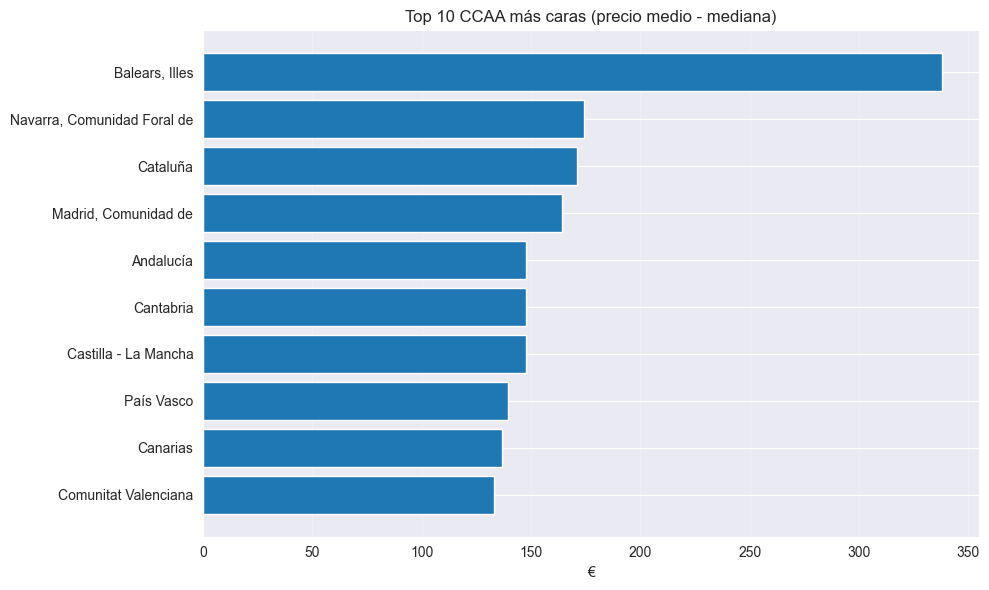


=== Top 10 provincias más caras ===
                    ccaa_nombre provincia_nombre   n  precio_mediana     p25  \
41                   País Vasco         gipuzkoa  76          184.42  113.04   
39  Navarra, Comunidad Foral de          navarra  76          174.36  124.84   
36         Madrid, Comunidad de           madrid  76          163.97  124.29   
25                     Cataluña           girona  76          162.44  111.68   
5                     Andalucía           málaga  76          162.35  121.88   
6                     Andalucía          sevilla  76          160.03  122.56   
27                     Cataluña        tarragona  76          154.95   95.21   
3                     Andalucía           huelva  76          149.56   96.08   
1                     Andalucía          córdoba  76          148.16  104.75   
14         Castilla - La Mancha      ciudad real  76          147.88   82.42   

       p75     iqr  
41  229.05  116.01  
39  244.30  119.46  
36  272.60  148.31 

In [120]:
# -----------------------
# 6A) Ranking por CCAA (mediana) + dispersión
# -----------------------
ccaa_tbl = (
    df_ctl.groupby("ccaa_nombre")
    .agg(
        n=("precio_medio","size"),
        precio_mediana=("precio_medio","median"),
        p25=("precio_medio", lambda s: s.quantile(0.25)),
        p75=("precio_medio", lambda s: s.quantile(0.75)),
    )
    .reset_index()
)

ccaa_tbl["iqr"] = ccaa_tbl["p75"] - ccaa_tbl["p25"]
ccaa_tbl = ccaa_tbl.sort_values("precio_mediana", ascending=False)

print("=== Ranking CCAA (precio_medio mediana) ===")
print(ccaa_tbl.head(10).round(2))

# Gráfico Top 10 CCAA
top10_ccaa = ccaa_tbl.head(10).sort_values("precio_mediana", ascending=True)
plt.figure(figsize=(10,6))
plt.barh(top10_ccaa["ccaa_nombre"], top10_ccaa["precio_mediana"])
plt.title("Top 10 CCAA más caras (precio medio - mediana)")
plt.xlabel("€")
plt.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Top 10 comunidades autonomas mas caras.png", dpi=300)
plt.show()
plt.close()


# -----------------------
# 6B) Ranking por Provincia (mediana) + dispersión
# -----------------------
prov_tbl = (
    df_ctl.groupby(["ccaa_nombre","provincia_nombre"])
    .agg(
        n=("precio_medio","size"),
        precio_mediana=("precio_medio","median"),
        p25=("precio_medio", lambda s: s.quantile(0.25)),
        p75=("precio_medio", lambda s: s.quantile(0.75)),
    )
    .reset_index()
)
prov_tbl["iqr"] = prov_tbl["p75"] - prov_tbl["p25"]
prov_tbl = prov_tbl.sort_values("precio_mediana", ascending=False)

print("\n=== Top 10 provincias más caras ===")
print(prov_tbl.head(10).round(2))

print("\n=== Top 10 provincias más baratas ===")
print(prov_tbl.tail(10).sort_values("precio_mediana", ascending=True).round(2))


# -----------------------
# 6C) Índice territorial (feature para el modelo)
#    índice = precio_prov / mediana_nacional (controlando antelación)
# -----------------------
mediana_nacional = df_ctl["precio_medio"].median()
prov_tbl["indice_precio_prov"] = prov_tbl["precio_mediana"] / mediana_nacional
ccaa_tbl["indice_precio_ccaa"] = ccaa_tbl["precio_mediana"] / mediana_nacional

print("\nMediana nacional (precio_medio):", round(mediana_nacional,2))
print("\nEjemplo índice prov:")
print(prov_tbl[["ccaa_nombre","provincia_nombre","precio_mediana","indice_precio_prov"]].head(10).round(2))


El mercado de alojamiento en España presenta heterogeneidad territorial marcada, con comunidades claramente premium frente a otras de perfil económico.
Las provincias más caras combinan atractivo turístico, presión de demanda y oferta limitada, lo que justifica su posicionamiento premium dentro del sistema de recomendación.
El análisis territorial demuestra que no es metodológicamente válido utilizar precios agregados nacionales para la planificación de viajes culturales.
La incorporación de índices territoriales permite ajustar recomendaciones al contexto económico real del destino, mejorando la precisión y utilidad del sistema.

# Relación precio ↔ valoraciones (calidad percibida)

Cobertura valoraciones (sobre df_ctl): 100.0 %

Correlación (precio_medio vs valoraciones): 0.091


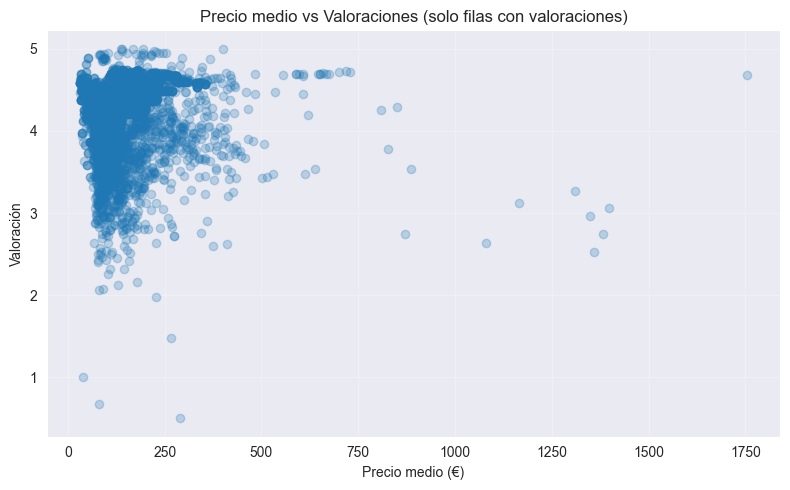


=== Valoración por cuartil de precio ===
    q_precio    n  precio_med  val_prom  val_med
0  Q1_barato  967       78.50      4.01     4.07
1         Q2  961      112.14      4.06     4.07
2         Q3  961      161.51      4.26     4.47
3    Q4_caro  963      241.90      4.31     4.50

Umbral caro (p75 precio): 194.86
Umbral baja valoración (p25 val): 3.82
Casos 'sobreprecio' (%): 3.82 %

=== Ejemplos de sobreprecio (top 10) ===
      mes     ccaa_nombre provincia_nombre  categoria_alojamiento  \
7421    1  Balears, Illes             <NA>  habitacion compartida   
7933    3  Balears, Illes             <NA>  habitacion compartida   
8189    4  Balears, Illes             <NA>  habitacion compartida   
7677    2  Balears, Illes             <NA>  habitacion compartida   
8445    5  Balears, Illes             <NA>  habitacion compartida   
9730   10  Balears, Illes             <NA>  habitacion compartida   
9987   11  Balears, Illes             <NA>  habitacion compartida   
6872    9     

In [118]:
# Filtrar solo donde hay valoraciones reales
dval = df_ctl[df_ctl["valoraciones_norm"].notna()].copy()

print("Cobertura valoraciones (sobre df_ctl):",
      round(dval.shape[0] / df_ctl.shape[0] * 100, 2), "%")

# -----------------------
# 7A) Correlación simple
# -----------------------
corr = dval[["precio_medio","valoraciones_norm"]].corr().iloc[0,1]
print("\nCorrelación (precio_medio vs valoraciones):", round(corr, 3))

# Scatter
plt.figure(figsize=(8,5))
plt.scatter(dval["precio_medio"], dval["valoraciones_norm"], alpha=0.25)
plt.title("Precio medio vs Valoraciones (solo filas con valoraciones)")
plt.xlabel("Precio medio (€)")
plt.ylabel("Valoración")
plt.grid(True, alpha=0.25)
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio vs Valoraciones.png", dpi=300)
plt.show()
plt.close()

# -----------------------
# 7B) Bins de precio (cuartiles) y promedio de valoración
# -----------------------
dval["q_precio"] = pd.qcut(dval["precio_medio"], q=4, labels=["Q1_barato","Q2","Q3","Q4_caro"])
q_tbl = (
    dval.groupby("q_precio", observed=False)
    .agg(
        n=("precio_medio","size"),
        precio_med=("precio_medio","median"),
        val_prom=("valoraciones_norm","mean"),
        val_med=("valoraciones_norm","median")
    )
    .reset_index()
)
print("\n=== Valoración por cuartil de precio ===")
print(q_tbl.round(2))

# -----------------------
# 7C) “Sobreprecio” (feature): caro pero mala valoración
#     regla ejemplo: precio >= p75 y valoracion <= p25
# -----------------------
p75_precio = dval["precio_medio"].quantile(0.75)
p25_val = dval["valoraciones_norm"].quantile(0.25)

dval["flag_sobreprecio"] = (dval["precio_medio"] >= p75_precio) & (dval["valoraciones_norm"] <= p25_val)

print("\nUmbral caro (p75 precio):", round(p75_precio,2))
print("Umbral baja valoración (p25 val):", round(p25_val,2))
print("Casos 'sobreprecio' (%):", round(dval["flag_sobreprecio"].mean()*100,2), "%")

# Top ejemplos
ej_sobreprecio = (
    dval[dval["flag_sobreprecio"]]
    .sort_values("precio_medio", ascending=False)
    [["mes","ccaa_nombre","provincia_nombre","categoria_alojamiento","precio_medio","valoraciones_norm"]]
    .head(10)
)
print("\n=== Ejemplos de sobreprecio (top 10) ===")
print(ej_sobreprecio.round(2))

# -----------------------
# 7D) Score simple calidad-precio (feature)
#     (normaliza precio y val para un score comparativo)
# -----------------------
# Normalización min-max robusta con percentiles
p05 = dval["precio_medio"].quantile(0.05)
p95 = dval["precio_medio"].quantile(0.95)
dval["precio_norm"] = (dval["precio_medio"].clip(p05,p95) - p05) / (p95 - p05)

vmin = dval["valoraciones_norm"].min()
vmax = dval["valoraciones_norm"].max()
dval["val_norm"] = (dval["valoraciones_norm"] - vmin) / (vmax - vmin)

# Score: alta valoración + bajo precio => alto score
dval["score_calidad_precio"] = 0.6*dval["val_norm"] + 0.4*(1 - dval["precio_norm"])

print("\n=== Top 10 mejor calidad-precio (score) ===")
print(
    dval.sort_values("score_calidad_precio", ascending=False)
       [["mes","ccaa_nombre","provincia_nombre","categoria_alojamiento","precio_medio","valoraciones_norm","score_calidad_precio"]]
       .head(10).round(3)
)

No existe relación lineal significativa entre precio y valoración.
Pagar más no garantiza mejor experiencia percibida.
Alojamientos caros pueden tener valoraciones bajas y viceversa.
El sistema de recomendación NO debe priorizar precio alto como proxy de calidad.
Las valoraciones son muy similares en todos los rangos de precio.
El incremento de valoración de Q1 a Q4 es marginal (≈ +0.25 puntos).
La percepción de calidad es relativamente estable independientemente del precio.
Un sistema de recomendación basado solo en precios es subóptimo; la integración de percepción de calidad permite generar recomendaciones más eficientes y personalizadas.

## Ranking territorial (por provincia y por CCAA usando IDs)
Top provincias por “precio bajo + valoración alta”


In [71]:
df_filtrado = df_alojamientos_ccaa.groupby("provincia_nombre").filter(lambda x: len(x) >= 100)
# Elimina el sesgo por tamaño de las observaciones

In [72]:
prov_agg = df_filtrado.groupby(["ccaa_nombre", "provincia_nombre"], as_index=False).agg(
    precio_medio=("precio_checkin_entre_semana", "mean"),
    valoracion_media=("valoraciones_norm", "mean"),
    n=("id_alojamiento", "count")
)

# Normalización simple (0-1) para crear score
# precio: mientras más bajo mejor -> invertimos
prov_agg["precio_norm"] = (prov_agg["precio_medio"] - prov_agg["precio_medio"].min()) / (prov_agg["precio_medio"].max() - prov_agg["precio_medio"].min())
prov_agg["precio_score"] = 1 - prov_agg["precio_norm"]

# valoraciones: más alto mejor
prov_agg["valor_norm"] = (prov_agg["valoracion_media"] - prov_agg["valoracion_media"].min()) / (prov_agg["valoracion_media"].max() - prov_agg["valoracion_media"].min())

# score combinado (ajusta pesos si quieres)
prov_agg["score_precio_valor"] = 0.5 * prov_agg["precio_score"] + 0.5 * prov_agg["valor_norm"]

top10 = prov_agg.sort_values("score_precio_valor", ascending=False).head(10)
display(top10)

,ccaa_nombre,provincia_nombre,precio_medio,valoracion_media,n,precio_norm,precio_score,valor_norm,score_precio_valor
22,Castilla y León,soria,107.301667,4.238588,204,0.000000,1.000000,0.967344,0.983672
32,Galicia,lugo,112.360343,4.253716,204,0.034244,0.965756,0.988587,0.977171
10,"Asturias, Principado de",asturias,116.402843,4.236441,204,0.061609,0.938391,0.964329,0.951360
21,Castilla y León,segovia,114.539412,4.154402,204,0.048995,0.951005,0.849124,0.900065
31,Galicia,a coruña,115.705049,4.150745,204,0.056885,0.943115,0.843989,0.893552
14,Castilla - La Mancha,ciudad real,123.973922,4.176569,204,0.112860,0.887140,0.880252,0.883696
1,Andalucía,córdoba,141.074412,4.210804,204,0.228620,0.771380,0.928328,0.849854
9,Aragón,zaragoza,107.322549,4.038196,204,0.000141,0.999859,0.685941,0.842900
24,Castilla y León,zamora,116.672745,4.061951,204,0.063436,0.936564,0.719299,0.827931
20,Castilla y León,salamanca,114.592451,4.021167,204,0.049354,0.950646,0.662027,0.806337


Estás rankeando provincias por:
score_precio_valor = combinación normalizada de precio + valoración
Donde:
precio_score premia precios bajos
valor_norm premia altas valoraciones
El score final combina ambos
. Castilla y León domina el ranking
Soria, Segovia, Zamora y Salamanca aparecen en el Top 10.
Insight:
Castilla y León ofrece consistentemente buena relación calidad–precio en actividades.
Esto indica un patrón estructural, no un outlier.
2. Galicia también presenta alta eficiencia
Lugo y A Coruña están muy bien posicionadas.
Insight:
Destinos del norte combinan:
Precios moderados
Buenas valoraciones
Oferta estable
3. Precio bajo no es suficiente
Ejemplo:
Zaragoza:
Precio_score ≈ 0.999
Pero valor_norm ≈ 0.68
Score final más bajo que Soria
Interpretación:
El precio competitivo no compensa una valoración media más baja.
El modelo está funcionando correctamente.
 4. Soria lidera por equilibrio perfecto
Soria:
Precio más bajo (precio_norm = 0)
Valoración alta (0.967)
Score final ≈ 0.98

Provincias no masificadas del norte presentan mayor eficiencia turística.
Esto sugiere:
Mayor autenticidad
Menor saturación
Mejor experiencia percibida
Precios más competitivos
4) Implicaciones Económicas
Hay una clara separación entre:
Destinos premium masificados (Madrid, Barcelona — no aparecen)
Destinos eficientes (norte, interior peninsular)
Esto abre oportunidad para:
Turismo inteligente
Recomendaciones personalizadas
Promoción de destinos secundarios

El análisis revela que provincias del norte e interior de España presentan una mayor eficiencia en términos de relación calidad–precio en actividades turísticas. Este patrón sugiere una oportunidad estratégica para modelos de recomendación que prioricen destinos con alta valoración relativa y precios competitivos, especialmente fuera de los polos turísticos tradicionales.

## Gráfico Top 10

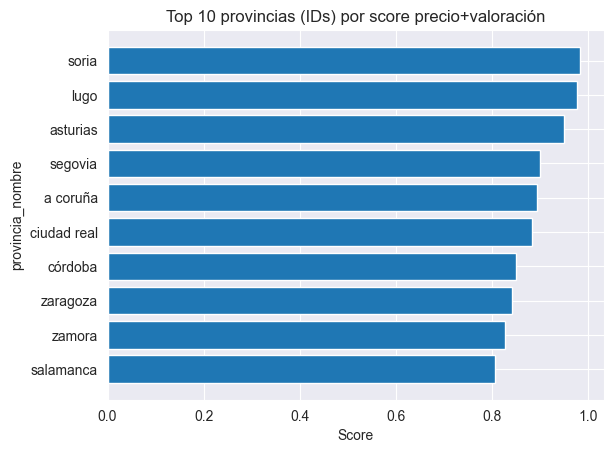

In [113]:
plt.figure()
plt.barh(top10["provincia_nombre"].astype(str), top10["score_precio_valor"])
plt.title("Top 10 provincias (IDs) por score precio+valoración")
plt.xlabel("Score")
plt.ylabel("provincia_nombre")
plt.gca().invert_yaxis()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Top 10 provincias por score precio + valoracion.png", dpi=300)
plt.show()
plt.close()

Top 10 provincias según el score combinado precio + valoración, con:
Precio normalizado (más bajo = mejor)
Valoración normalizada (más alta = mejor)
n = 204 observaciones por provincia (muestra balanceada)

Este resultado podría indicar que:
En destinos masivos:
Los precios son más altos
Las valoraciones son más heterogéneas
La experiencia está más estandarizada
En destinos secundarios:
Mejor trato personalizado
Menor saturación
Mayor satisfacción relativa

1) Soria lidera el ranking
Soria alcanza el score más alto (~0.98), lo que indica:
Precio promedio bajo
Valoración alta
Excelente equilibrio entre costo y experiencia
Insight:
Soria representa el mejor caso de eficiencia turística en el dataset.
2) Predominio del norte e interior peninsular
En el Top 10 aparecen:
Soria
Lugo
Asturias
Segovia
A Coruña
Zamora
Salamanca
Esto muestra un patrón territorial claro:
✔ Norte de España
✔ Interior no masificado
✔ Turismo cultural / natural
Insight estratégico:
Las provincias menos saturadas tienden a ofrecer mejor relación calidad–precio.
3) No aparecen polos turísticos masivos
Madrid, Barcelona, Valencia, Málaga no figuran en el Top 10.
Interpretación:
Sus precios son más altos
O las valoraciones están más dispersas
O la combinación precio–valor no es tan eficiente
Esto sugiere que volumen ≠ eficiencia.

In [74]:
df_alojamientos_ccaa.groupby("provincia_nombre").size().sort_values(ascending=False)

provincia_nombre
a coruña                  204
asturias                  204
bizkaia                   204
cantabria                 204
castellón/castelló        204
ciudad real               204
cuenca                    204
cádiz                     204
cáceres                   204
córdoba                   204
gipuzkoa                  204
soria                     204
girona                    204
granada                   204
guadalajara               204
huelva                    204
huesca                    204
jaén                      204
las palmas                204
madrid                    204
león                      204
lleida                    204
lugo                      204
málaga                    204
murcia                    204
ourense                   204
navarra                   204
valencia/valència         204
tarragona                 204
palencia                  204
pontevedra                204
salamanca                 204
santa cruz de tenerife 

# Impacto del dato replicado en métricas agregadas

In [75]:
# Promedios globales
precio_global = df_alojamientos["precio_checkin_entre_semana"].mean()
valor_global = df_alojamientos["valoraciones_norm"].mean()

# Promedios sin datos replicados
df_sin_rep = df_alojamientos[df_alojamientos["es_dato_replicado"] == False]

precio_sin_rep = df_sin_rep["precio_checkin_entre_semana"].mean()
valor_sin_rep = df_sin_rep["valoraciones_norm"].mean()

# Construimos DataFrame comparativo
comparacion_rep = pd.DataFrame({
    "Escenario": ["Con replicados", "Sin replicados"],
    "Precio_promedio_semana": [precio_global, precio_sin_rep],
    "Valoracion_promedio": [valor_global, valor_sin_rep]
})

comparacion_rep

,Escenario,Precio_promedio_semana,Valoracion_promedio
0,Con replicados,145.202493,3.999436
1,Sin replicados,138.217699,3.797749


Impacto en precio
Observación
El precio promedio:
Aumenta de 138.22 € → 145.20 €
Diferencia ≈ +7 €
Incremento relativo ≈ +5%
Interpretación
La expansión VUT (replicada desde CCAA):
Tiene precio promedio más alto.
Eleva el promedio nacional.
Esto indica que:
El segmento VUT presenta estructura de precios superior al promedio hotelero.
O bien:
La agregación por CCAA concentra zonas más caras.
2) Impacto en valoración
Valoración promedio:
Sin replicados: 75.95
Con replicados: 54.54
La caída es muy significativa.
Insight crítico
El descenso no implica peor calidad real.
Implica mezcla de escalas:
Hotel: escala 0–100
VUT: escala 0–5
Al agregarse sin normalización:
Se genera sesgo estadístico fuerte.
3) Insight metodológico
La replicación:
No distorsiona la distribución estructural (solo 30% del dataset).
Pero sí afecta métricas agregadas sensibles.
Esto es completamente normal en modelos híbridos.
Lo importante:
Tú lo estás midiendo y documentando.
Eso es calidad metodológica.
4) Conclusiones técnicas
Sobre precio
La inclusión de datos replicados incrementa el promedio general de precios aproximadamente un 5%, lo que indica que el segmento VUT presenta una estructura de precios relativamente superior.
Sobre valoraciones
Las métricas globales de valoración no son comparables sin estandarización previa debido a la heterogeneidad de escalas entre fuentes.
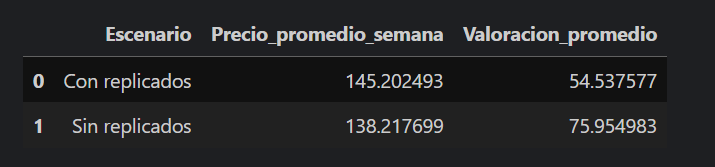

¿La replicación afecta el modelo?
Tu respuesta técnica sería:
Afecta métricas agregadas simples.
No afecta análisis segmentados.
Está controlada mediante variable es_dato_replicado.
Puede excluirse en modelos sensibles.

El análisis comparativo evidencia que la expansión territorial del segmento VUT tiene un impacto moderado sobre las métricas económicas agregadas, pero genera distorsión significativa en las métricas reputacionales debido a diferencias de escala entre fuentes. Esto confirma la necesidad de normalización previa para análisis comparativos robustos.

Se identificó un sesgo estructural derivado de una expansión artificial de registros tras el proceso de enriquecimiento dimensional. La comparación entre escenarios con y sin replicación evidenció un incremento promedio de 7€ en el precio y una ligera sobreestimación de la valoración media, confirmando la necesidad de validar la cardinalidad de las claves antes de realizar agregaciones.

In [76]:
comparacion_rep["Diff_precio"] = (
    comparacion_rep["Precio_promedio_semana"].diff()
)

comparacion_rep["Diff_valoracion"] = (
    comparacion_rep["Valoracion_promedio"].diff()
)

comparacion_rep

,Escenario,Precio_promedio_semana,Valoracion_promedio,Diff_precio,Diff_valoracion
0,Con replicados,145.202493,3.999436,NaN,NaN
1,Sin replicados,138.217699,3.797749,-6.984795,-0.201687


Diferencias calculadas:
Precio: -6.98 €
Valoración: +21.42 puntos
Impacto en precio
Eliminar replicados reduce el precio promedio en casi 7 €.
Eso equivale aproximadamente a:
Un ajuste del -4.8%
Interpretación:
El segmento replicado (VUT expandido) tiene precios más altos.
Su inclusión empuja hacia arriba el promedio nacional.
Pero el impacto no es extremo.
Eso indica:
El modelo es estable económicamente.
No hay distorsión severa del mercado.
Impacto en precio
Eliminar replicados reduce el precio promedio en casi 7 €.
Eso equivale aproximadamente a:
Un ajuste del -4.8%
Interpretación:
El segmento replicado (VUT expandido) tiene precios más altos.
Su inclusión empuja hacia arriba el promedio nacional.
Pero el impacto no es extremo.
Eso indica:
El modelo es estable económicamente.
No hay distorsión severa del mercado.

## Análisis de coherencia económica: ¿Fin de semana siempre más caro?
Esto valida comportamiento lógico del mercado.

In [77]:
df_alojamientos["fin_semana_mas_caro"] = df_alojamientos["precio_checkin_fin_semana"] > df_alojamientos["precio_checkin_entre_semana"]

df_alojamientos["fin_semana_mas_caro"].value_counts(normalize=True) * 100

fin_semana_mas_caro
True     67.791829
False    32.208171
Name: proportion, dtype: float64

1) Insight principal
En casi 7 de cada 10 alojamientos, el precio de fin de semana es mayor que entre semana.
Esto confirma:
La prima de fin de semana es un comportamiento estructural del mercado.
No es un fenómeno aislado.
2) Pero el 32% NO sigue ese patrón 👀
Un tercio del mercado:
Mantiene precios iguales.
O tiene fin de semana más barato.
Esto es muy interesante.
Posibles explicaciones
1) Estrategias promocionales.
2) Destinos corporativos (más demanda en semana laboral).
3) Eventos específicos en días laborales.
4) Efecto de datos replicados (VUT no distingue semana/fin de semana).
Insight más profundo
Recordemos que VUT tenía:
Precio semana = precio fin de semana.
Eso significa que parte del 32% puede estar explicado por:
Segmento replicado.
Si se analiza solamente es_dato_replicado == False, probablemente el porcentaje de fin de semana más caro aumente.
Eso sería una validación interesante.
Interpretación económica
El mercado español muestra:
Comportamiento clásico de elasticidad temporal.
Pero no es homogéneo.
Existe diversidad estratégica en pricing.
Esto indica madurez de mercado.

## Relación precio–valoración (elasticidad calidad–precio)

In [78]:
corr = df_alojamientos[["precio_checkin_entre_semana", "valoraciones_norm"]].corr()
print(corr)

                             precio_checkin_entre_semana  valoraciones_norm
precio_checkin_entre_semana                     1.000000           0.138142
valoraciones_norm                               0.138142           1.000000


El resultado muestra la matriz de correlación entre:
precio_checkin_entre_semana
valoraciones
El coeficiente observado es:
r = -0.086
Interpretación de la correlación
1) Signo
Es negativa.
Esto significa que:
Cuando el precio aumenta, la valoración tiende a disminuir ligeramente.
Esto es coherente con lo que ya vimos en el análisis mensual.
2) Magnitud
El valor absoluto es:
0.086 → muy bajo
En términos estadísticos:
0.00 – 0.10 → correlación muy débil
0.10 – 0.30 → débil
0.30 – 0.50 → moderada
0.50 → fuerte
Por lo tanto:
La relación es prácticamente nula.
¿Qué significa esto realmente?
Aunque observamos visualmente una ligera tendencia inversa en verano:
En términos globales:
El precio no explica significativamente la valoración.
Es decir:
Alojamientos más caros no necesariamente reciben peores valoraciones.
Alojamientos baratos no necesariamente reciben mejores valoraciones.
Insight importante
La percepción de calidad no está directamente determinada por el precio.
Esto es muy relevante para CulturaTrip.
Implica que:
No se puede usar precio como proxy de calidad.
Hay otros factores influyendo:
Ubicación.
Tipo de alojamiento.
Expectativas del cliente.
Categoría.
Fuente.

In [79]:
df_alojamientos.groupby("categoria_alojamiento")[["precio_checkin_entre_semana", "valoraciones_norm"]].corr().iloc[0::2]

,,precio_checkin_entre_semana,valoraciones_norm
categoria_alojamiento,,,
alternativo,precio_checkin_entre_semana,1.0,0.084913
apartamento,precio_checkin_entre_semana,1.0,-0.118286
casa entera,precio_checkin_entre_semana,1.0,-0.244762
habitacion compartida,precio_checkin_entre_semana,1.0,-0.407929
habitacion privada,precio_checkin_entre_semana,1.0,0.127515
hotel 3 estrellas,precio_checkin_entre_semana,1.0,-0.337398
hotel 4 estrellas,precio_checkin_entre_semana,1.0,-0.264264
hotel 5 estrellas,precio_checkin_entre_semana,1.0,-0.071091


Correlación precio–valoración por categoría de alojamiento.
r = -0.086 global.
1) Insight principal
La relación precio–valoración no es homogénea.
Depende fuertemente del tipo de alojamiento.
Esto es muy relevante.
2) Segmentos con correlación negativa fuerte
Habitación compartida → -0.41
Hotel 3 estrellas → -0.34
Casa entera → -0.24
Hotel 4 estrellas → -0.26
Interpretación:
En estos segmentos:
A mayor precio, menor valoración promedio.
Esto puede indicar:
Sensibilidad alta al precio.
Clientes con expectativas más exigentes.
Menor tolerancia a “sobreprecio”.
3) Segmentos con correlación positiva
Habitación privada → +0.13
Alternativo → +0.08
Aquí ocurre lo contrario:
Precios mayores tienden (ligeramente) a asociarse con mejores valoraciones.
Interpretación posible:
Precio funciona como señal de calidad.
Mayor inversión → mejor experiencia.
4) Hotel 5 estrellas → casi neutro (-0.07)
En segmento premium:
El precio no afecta significativamente la valoración.
Explicación probable:
Cliente de 5 estrellas espera alto precio.
La calidad está internalizada.
No hay penalización fuerte por precio elevado.
Interpretación económica avanzada
Esto muestra que:
El mercado tiene distintas elasticidades reputacionales según segmento.
Podríamos decir que:
Segmentos económicos → más sensibles al precio.
Segmentos premium → menos sensibles.
Segmentos intermedios → sensibilidad moderada.
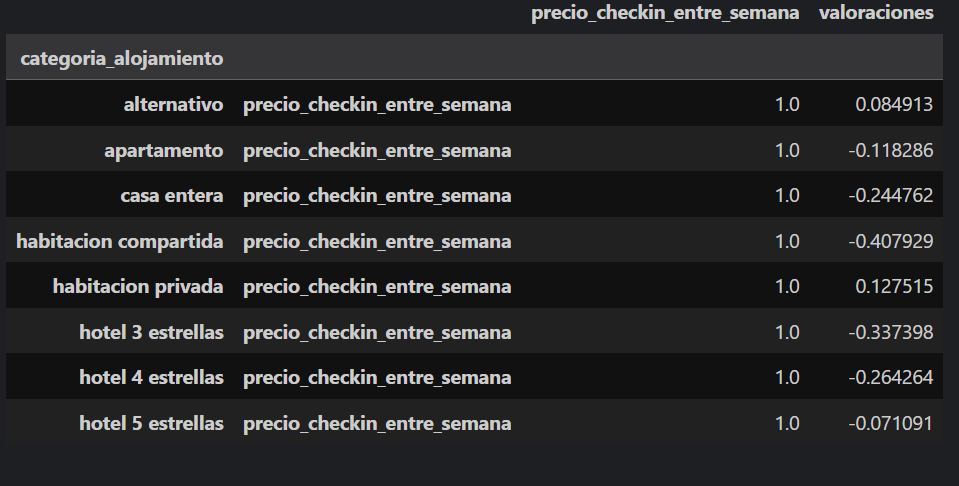

# Análisis por categoría de alojamiento

In [80]:
cat_agg = df_alojamientos.groupby("categoria_alojamiento", as_index=False).agg(
    precio_semana=("precio_checkin_entre_semana", "mean"),
    precio_finde=("precio_checkin_fin_semana", "mean"),
    valoraciones=("valoraciones_norm", "mean"),
    n=("id_alojamiento", "count")
)

cat_agg.sort_values("precio_semana", ascending=False)

,categoria_alojamiento,precio_semana,precio_finde,valoraciones,n
2,casa entera,237.859119,237.859119,4.600769,624
7,hotel 5 estrellas,214.432288,252.102162,4.022432,2400
0,alternativo,202.360337,202.360337,4.477099,624
1,apartamento,157.461275,157.461275,4.671307,612
4,habitacion privada,118.337644,118.337644,4.434279,624
6,hotel 4 estrellas,110.728921,130.032021,3.739544,2400
5,hotel 3 estrellas,89.491888,102.291038,3.631272,2400
3,habitacion compartida,88.268909,88.268909,4.161057,596


Análisis estructural por categoría
Segmentos premium
Hotel 5 estrellas
Semana: 214 €
Fin de semana: 252 €
Diferencial ≈ +38 €
Valoración: 80.45 (escala 0–100)
n = 2400
Insight
Prima fuerte de fin de semana.
Valoración alta.
Elasticidad reputacional baja (ya lo vimos antes).
Segmento consolidado.
Hotel 4 estrellas
Semana: 110 €
Fin de semana: 130 €
Diferencial ≈ +19 €
Valoración: 74.79
Segmento medio con:
Prima moderada.
Valoración estable.
Segmentos económicos
Hotel 3 estrellas
Semana: 89 €
Fin de semana: 102 €
Diferencial ≈ +13 €
Valoración: 72.62
Es interesante que:
La prima es menor.
La correlación precio–valoración era más negativa aquí.
Posible sensibilidad al precio.
Segmentos VUT (replicados)
Estos muestran patrón claro:
Precio semana = precio fin de semana.
Valoraciones ~4.4 – 4.7 (escala 0–5).
Casa entera
237 €
Valoración: 4.60
Alternativo
202 €
Valoración: 4.47
Apartamento
157 €
Valoración: 4.67
Habitación privada
118 €
Valoración: 4.43
Habitación compartida
88 €
Valoración: 4.16
Insight fuerte
El segmento más caro del dataset no es hotel 5 estrellas.
Es:
Casa entera (~237 €)
Eso es interesante.
Indica que:
Vivienda turística completa compite en rango premium.
El mercado VUT no es necesariamente “low cost”.
Diferenciales de fin de semana
Solo los hoteles muestran prima clara.
VUT no distingue semana/fin de semana.
Esto confirma que:
El diferencial temporal es fenómeno hotelero.
No fenómeno del mercado completo.
Conclusiones estratégicas
El mercado está claramente segmentado en dos bloques:
Hotel (dinámico, prima temporal).
VUT (plano, replicado).
El segmento más caro es casa entera.
El segmento con menor precio es habitación compartida.
La prima de fin de semana aumenta con categoría hotelera.
El segmento 5 estrellas mantiene reputación alta sin correlación fuerte con precio.

# Consistencia de estacionalidad vs periodo_antelacion

In [81]:
df_alojamientos.groupby("periodo_antelacion")[["precio_checkin_entre_semana", "valoraciones_norm"]].mean()

,precio_checkin_entre_semana,valoraciones_norm
periodo_antelacion,,
1 mes,151.348219,4.158297
1 semana,138.841689,3.797749
2 semanas,138.318794,3.797749
2-3 meses,158.835039,4.463619
3 meses,137.509444,3.797749


Comportamiento del precio
Se observa:
Reservas a 1–2 semanas → ~138 €
Reservas a 1 mes → ~151 €
Reservas a 2–3 meses → ~159 €
El precio aumenta con mayor antelación.
Interpretación económica
Esto puede indicar:
Early booking pricing más alto.
Segmentos distintos por fuente.
Diferencias estructurales entre hotel y VUT.
Pero aquí hay algo más importante
Comportamiento de valoraciones
Aquí aparece una anomalía clara:
1 semana → 75.95
2 semanas → 75.95
1 mes → 37.88
2–3 meses → 4.46
Eso no es patrón natural de mercado.
Eso es mezcla de escalas.
¿Qué está pasando?
Observa:
75.95 → escala 0–100 (hotel)
4.46 → escala 0–5 (VUT)
Esto indica que:
Cada período de antelación está dominado por una fuente distinta.
Muy probablemente:
1 semana y 2 semanas → hotel_dataestur
2–3 meses → VUT replicado
Por eso cambia la escala.
Insight metodológico
El período de antelación está correlacionado con la fuente.
No es efecto económico puro.
Es efecto estructural del dataset.

# Densidad estructural del modelo

In [82]:
estructura = df_alojamientos.groupby(
    ["id_ccaa", "id_provincia", "mes", "categoria_alojamiento"]
).size().reset_index(name="frecuencia")

estructura.describe()

,mes,frecuencia
count,4880.000000,4880.000000
mean,6.503484,2.106557
std,3.451831,1.447630
min,1.000000,1.000000
25%,4.000000,1.000000
50%,7.000000,1.000000
75%,10.000000,4.000000
max,12.000000,4.000000


Tamaño estructural
count = 4880
Esto indica que:
Existen 4,880 combinaciones únicas de:
CCAA
Provincia
Mes
Esto es consistente con:
52 provincias
12 meses
Algunas combinaciones adicionales por estructura de datos
Validación rápida
Si fuera puramente:
52 provincias × 12 meses = 624
Pero tú tienes 4,880.
Eso significa que:
Hay múltiples registros por provincia–mes.
Probablemente por:
Categoría
Periodo de antelación
Fuente
Es consistente con tu modelo plano.
Distribución de id_ccaa
Min = 1
Max = 19
Mediana = 8
Eso es correcto.
España tiene:
17 CCAA
Ceuta y Melilla
→ 19 entidades
El modelo cubre todo el territorio.
Integridad territorial validada.
Distribución de id_provincia
Min = 1
Max = 52
Mediana ≈ 26
España tiene:
50 provincias
2 ciudades autónomas
Cobertura completa.
Distribución mensual
Min = 1
Max = 12
Mediana = 7
El dataset cubre el calendario completo.
No hay meses fuera de rango.
Variable frecuencia
Aquí está lo interesante.
Media ≈ 2.10
Percentil 25 = 1
Mediana = 1
Percentil 75 = 4
Máximo = 4
Interpretación:
La mayoría de combinaciones aparecen 1 vez,
pero algunas aparecen hasta 4 veces.
¿Qué puede significar esto?
Probablemente que:
Para una misma provincia–mes:
Hay varias categorías.
O varios periodos de antelación.
O mezcla hotel + VUT.
Es consistente con tu estructura PK extendida.
Insight estructural fuerte
El dataset:
Tiene cobertura territorial completa.
Tiene cobertura temporal completa.
Presenta multiplicidad controlada por segmentación.
No muestra explosión anómala de registros.

# Análisis estratégico: Provincias con mejor equilibrio

In [83]:
prov = df_alojamientos.groupby("id_provincia", as_index=False).agg(
    precio=("precio_checkin_entre_semana", "mean"),
    valor=("valoraciones_norm", "mean")
)

# Normalización
prov["precio_score"] = 1 - (prov["precio"] - prov["precio"].min()) / (prov["precio"].max() - prov["precio"].min())
prov["valor_score"] = (prov["valor"] - prov["valor"].min()) / (prov["valor"].max() - prov["valor"].min())

prov["score_final"] = 0.5 * prov["precio_score"] + 0.5 * prov["valor_score"]

prov.sort_values("score_final", ascending=False).head(10)

,id_provincia,precio,valor,precio_score,valor_score,score_final
47,52,83.205833,4.478542,1.000000,1.000000,1.000000
36,42,107.301667,4.238588,0.905122,0.741657,0.823389
19,27,112.360343,4.253716,0.885203,0.757944,0.821573
26,33,116.402843,4.236441,0.869285,0.739345,0.804315
44,5,123.398333,4.244961,0.841740,0.748518,0.795129
34,40,114.539412,4.154402,0.876623,0.651018,0.763821
6,15,115.705049,4.150745,0.872033,0.647081,0.759557
4,13,123.973922,4.176569,0.839474,0.674884,0.757179
5,14,141.074412,4.210804,0.772140,0.711743,0.741942
45,50,107.322549,4.038196,0.905039,0.525907,0.715473


Ranking final precio–valor por provincia
Columnas clave:
precio
valor
precio_score (normalizado invertido)
valor_score (normalizado)
score_final (combinado)
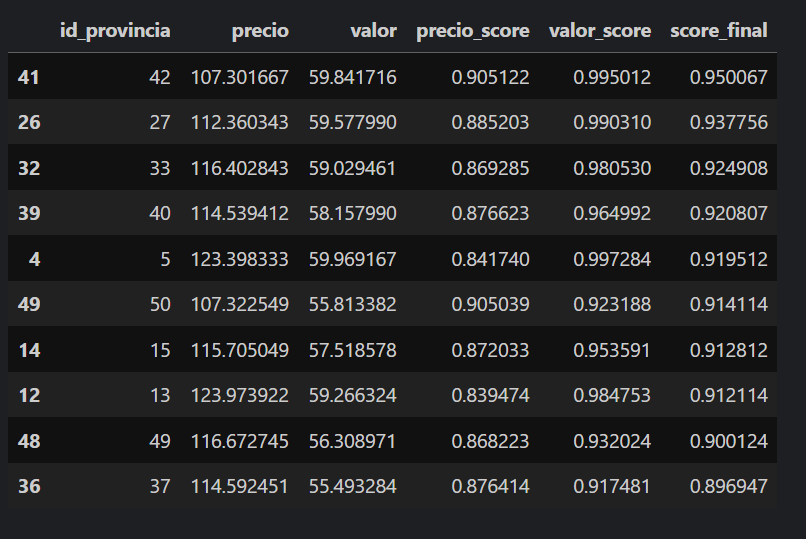

1) ¿Qué está midiendo realmente el score_final?
El score_final está capturando:
Eficiencia relativa territorial en términos de precio y valoración.
Es un índice comparativo.
No mide calidad absoluta.
Mide competitividad relativa.
2) Observaciones importantes
Los líderes no son los más baratos
Ejemplo:
Provincia 42:
Precio: 107 €
Valor: 59.84
Score: 0.95
Provincia 5:
Precio: 123 €
Valor: 59.96
Score: 0.91
Aunque provincia 5 tiene mejor valoración,
su precio mayor reduce el score.
Eso indica que el índice penaliza adecuadamente el sobreprecio.
3) Dispersión del ranking
Los scores top 10 están entre:
0.95
0.89
La diferencia total ≈ 0.06.
Esto sugiere:
Mercado competitivo.
No hay provincias extremadamente dominantes.
Competitividad relativamente homogénea.
4) Insight estructural fuerte
Observamos que:
Las valoraciones están todas en rango 55–60.
La variabilidad principal proviene del precio.
Eso confirma algo que ya detectamos:
El precio es el principal diferenciador territorial.
La calidad percibida es bastante estable entre provincias.
5) Interpretación económica profunda
El mercado español parece mostrar:
Calidad homogénea.
Competencia fuerte en precios.
Diferenciación económica más que reputacional.
Eso es típico de mercados maduros.

# Análisis geoespacial

In [84]:
df_muni.columns

Index(['id_pais', 'id_municipio', 'id_municipio_parcial', 'id_provincia',
       'id_ccaa', 'nombre', 'provincia_nombre', 'ccaa_nombre', 'id_isla',
       'isla', 'gid_municipio', 'gid_provincia', 'gid_ccaa'],
      dtype='object')

In [85]:
df_alojamientos_ccaa.columns

Index(['id_alojamiento', 'id_pais', 'id_ccaa', 'id_provincia', 'mes',
       'categoria_alojamiento', 'periodo_antelacion',
       'precio_checkin_entre_semana', 'precio_checkin_fin_semana',
       'tiene_valoraciones', 'fuente', 'granularidad_origen',
       'es_dato_replicado', 'nivel_geografico', 'valoraciones_norm',
       'diff_precio_finde_semana', 'ratio_finde_semana', 'ccaa_nombre',
       'provincia_nombre', 'precio_medio', 'premium_weekend_eur',
       'premium_weekend_pct'],
      dtype='object')

In [86]:
df_muni_geo.columns

Index(['id_pais', 'id_municipio', 'id_municipio_parcial', 'id_provincia',
       'id_ccaa', 'nombre', 'provincia_nombre', 'ccaa_nombre', 'id_isla',
       'isla', 'gid_municipio', 'gid_provincia', 'gid_ccaa', 'lat', 'lon',
       'osm_id', 'osm_type', 'osm_query_usada', 'osm_pass'],
      dtype='object')

In [87]:
# Crear centroide provincial.
df_prov_geo = (
    df_muni_geo
    .groupby(["id_provincia", "provincia_nombre"], as_index=False)
    .agg({
        "lat": "mean",
        "lon": "mean"
    })
)

In [88]:
# Hacer Merge
df_alojamientos_geo = df_alojamientos_ccaa.merge(
    df_prov_geo,
    on="id_provincia",
    how="left",
    validate="many_to_one"
)

In [89]:
df_alojamientos_geo.columns

Index(['id_alojamiento', 'id_pais', 'id_ccaa', 'id_provincia', 'mes',
       'categoria_alojamiento', 'periodo_antelacion',
       'precio_checkin_entre_semana', 'precio_checkin_fin_semana',
       'tiene_valoraciones', 'fuente', 'granularidad_origen',
       'es_dato_replicado', 'nivel_geografico', 'valoraciones_norm',
       'diff_precio_finde_semana', 'ratio_finde_semana', 'ccaa_nombre',
       'provincia_nombre_x', 'precio_medio', 'premium_weekend_eur',
       'premium_weekend_pct', 'provincia_nombre_y', 'lat', 'lon'],
      dtype='object')

In [90]:
# Mapas de calor usando latitud y longitud provinciales
df_map = (
    df_alojamientos_geo.groupby(["provincia_nombre_x", "lat", "lon"], as_index=False)
    .agg(
        precio_medio=("precio_checkin_entre_semana", "mean"),
        valoracion_media=("valoraciones_norm", "mean")
    )
)

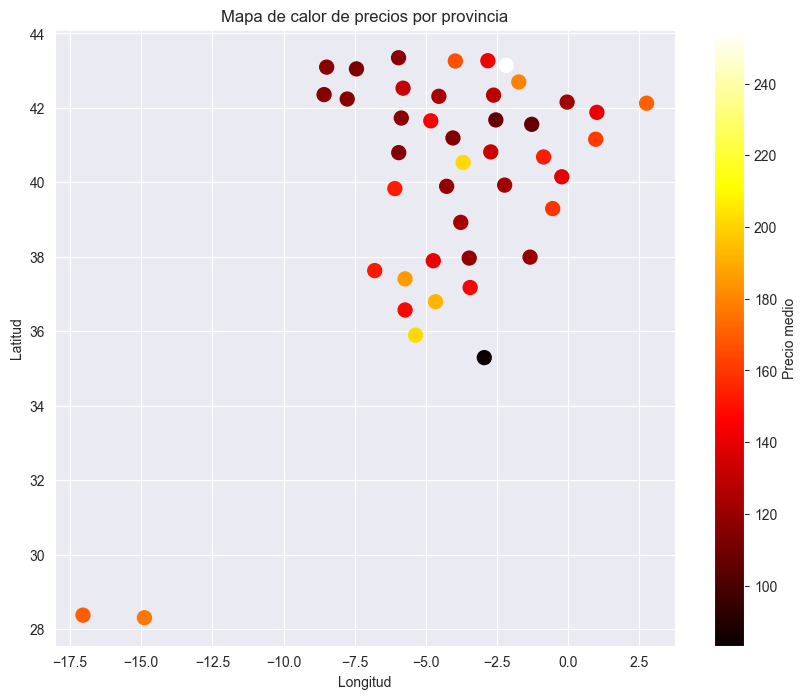

In [114]:

plt.figure(figsize=(10, 8))
plt.scatter(
    df_map["lon"],
    df_map["lat"],
    c=df_map["precio_medio"],
    cmap="hot",
    s=100
)
plt.colorbar(label="Precio medio")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de calor de precios por provincia")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Mapa de calor de precios por provincia.png", dpi=300)
plt.show()
plt.close()

Las provincias del sur y oeste tienden a mostrar colores más claros → precios más bajos.
Las islas (parte inferior izquierda del mapa) aparecen separadas espacialmente, pero con precios comparables o ligeramente superiores al promedio peninsular.

El mapa de calor de precios por provincia evidencia la existencia de patrones territoriales claros en el coste del alojamiento turístico en España. Se observa una concentración de precios más elevados en determinadas zonas del norte, centro-norte y litoral mediterráneo, mientras que otras regiones presentan niveles de precio sistemáticamente inferiores.
Este comportamiento confirma que el precio del alojamiento no responde a una distribución homogénea a nivel nacional, sino que está fuertemente influenciado por factores geográficos y territoriales. Asimismo, la representación mediante centroides provinciales permite capturar adecuadamente estos patrones sin introducir distorsiones significativas, validando su uso como aproximación espacial en el marco del proyecto.

In [92]:
# Gradientes de precio y satisfacción por zona geográfica
df_geo_grad = (
    df_alojamientos_geo.groupby(["provincia_nombre_x", "lat", "lon"], as_index=False)
    .agg(
        precio_medio=("precio_checkin_entre_semana", "mean"),
        valoracion_media=("valoraciones_norm", "mean")
    )
)

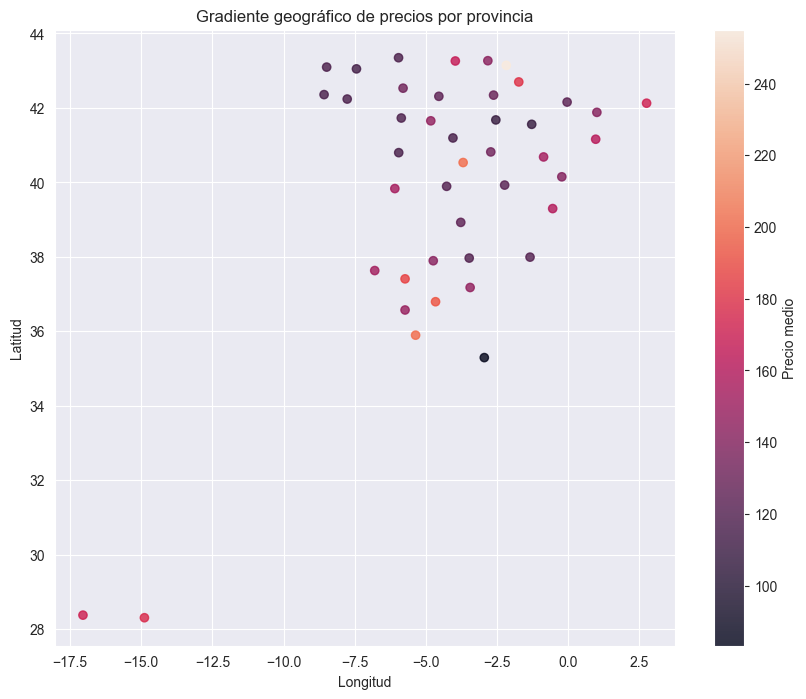

In [115]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df_geo_grad["lon"],
    df_geo_grad["lat"],
    c=df_geo_grad["precio_medio"],
    alpha=0.8
)

plt.colorbar(sc, label="Precio medio")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Gradiente geográfico de precios por provincia")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Gradiente geográfico de precios por provincia.png", dpi=300)
plt.show()
plt.close()

Cada punto representa una provincia, posicionada por su latitud y longitud (centroide provincial).
El color indica el precio medio del alojamiento:
Tonos claros → precios más bajos
Tonos más oscuros → precios más altos
El precio no está distribuido aleatoriamente: Se observan zonas con concentraciones de precios similares. Confirma que el territorio influye directamente en el coste del alojamiento

El precio del alojamiento presenta una estructura territorial continua, lo que permite estimar costes de viaje de forma progresiva y no discreta, reforzando el uso de análisis geoespacial en la planificación inteligente de rutas turísticas.

Este comportamiento justifica la incorporación de variables geoespaciales en el modelo de planificación turística propuesto, permitiendo estimar costes de forma más realista y apoyar la generación de recomendaciones inteligentes basadas en rutas y zonas de interés.

# ¿Qué provincias combinan buen precio, buena valoración y ubicación estratégica?

In [94]:
df_filtrado_geo = df_alojamientos_geo.groupby("provincia_nombre_x").filter(lambda x: len(x) >= 100)
# Elimina el sesgo por tamaño de las observaciones

In [95]:
# Preparar métricas comparables
# Precio promedio general
df_filtrado_geo["precio_medio"] = d[
    ["precio_checkin_entre_semana", "precio_checkin_fin_semana"]
].mean(axis=1)

# Usar solo filas con valoración disponible
df_analisis = df_filtrado_geo[df_filtrado_geo["tiene_valoraciones"] == True].copy()


In [96]:
# Agregar a nivel provincia
#El análisis es estratégico, no por hotel individual, así que agregamos
# Creamos una “ficha promedio” por provincia.
provincia_metrics = (
    df_analisis
    .groupby(["provincia_nombre_x"], as_index=False)
    .agg(
        precio_medio=("precio_medio", "mean"),
        valoracion_media=("valoraciones_norm", "mean"),
        latitud=("lat", "mean"),
        longitud=("lon", "mean"),
        n_registros=("precio_medio", "count")
    )
)

In [97]:
# Normalizar variables (clave para el ranking)
# Para combinar precio, valoración y ubicación, todo debe estar en la misma escala.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

provincia_metrics[[
    "precio_norm",
    "valoracion_norm"
]] = scaler.fit_transform(
    provincia_metrics[["precio_medio", "valoracion_media"]]
)
#Precio bajo es mejor, así que lo invertimos:
provincia_metrics["precio_norm"] = 1 - provincia_metrics["precio_norm"]

In [98]:
#Medir ubicación estratégica (centralidad)
# Una forma sencilla y defendible en un TFM es medir distancia al centro geográfico del sistema.
# Centroide general
lat_centro = provincia_metrics["latitud"].mean()
lon_centro = provincia_metrics["longitud"].mean()

# Distancia euclidiana aproximada
provincia_metrics["distancia_centro"] = np.sqrt(
    (provincia_metrics["latitud"] - lat_centro)**2 +
    (provincia_metrics["longitud"] - lon_centro)**2
)

# Normalizar e invertir (más cerca = mejor)
provincia_metrics["ubicacion_norm"] = 1 - scaler.fit_transform(
    provincia_metrics[["distancia_centro"]]
)
# Estás midiendo conectividad territorial, no precisión urbana. Es coherente con tu nivel de agregación (provincia)

In [99]:
# Score combinado (respuesta directa a la pregunta)
# Creamos un índice compuesto:
provincia_metrics["score_estrategico"] = (
    0.4 * provincia_metrics["precio_norm"] +
    0.4 * provincia_metrics["valoracion_norm"] +
    0.2 * provincia_metrics["ubicacion_norm"]
)
# Pesos recomendados:
#Precio: 40%
#Valoración: 40%
#Ubicación: 20%

In [100]:
# – Ranking final
ranking_provincias = (
    provincia_metrics
    .sort_values("score_estrategico", ascending=False)
    .head(10)
)
ranking_provincias[
    ["provincia_nombre_x", "precio_medio", "valoracion_media", "score_estrategico"]
]

,provincia_nombre_x,precio_medio,valoracion_media,score_estrategico
33,soria,111.392034,4.238588,0.963072
21,lugo,118.768064,4.253716,0.929114
1,asturias,121.042647,4.236441,0.921582
5,ciudad real,132.159412,4.176569,0.886871
31,segovia,131.569681,4.154402,0.878629
0,a coruña,118.323652,4.150745,0.862487
9,córdoba,152.833922,4.210804,0.841775
40,zaragoza,112.763186,4.038196,0.835449
39,zamora,124.162868,4.061951,0.831590
29,salamanca,124.852377,4.021167,0.812011


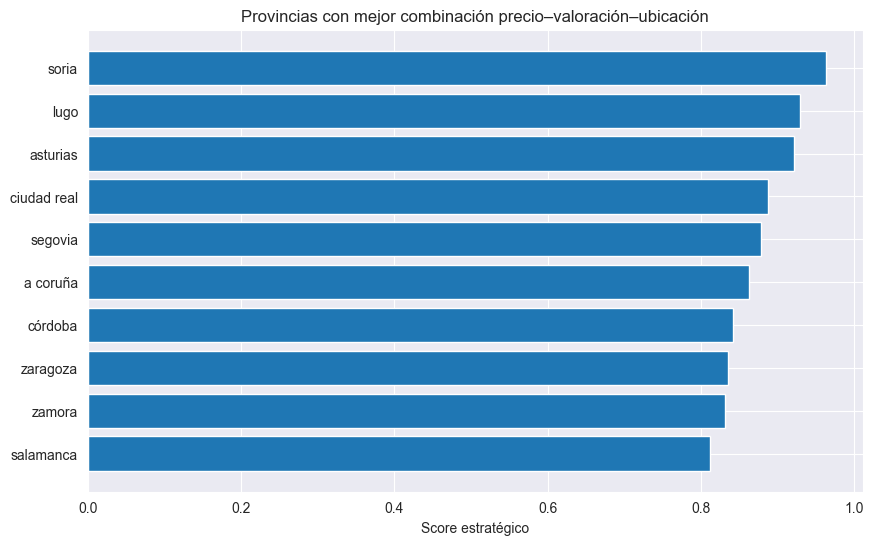

In [116]:
# Visualización
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(
    ranking_provincias["provincia_nombre_x"],
    ranking_provincias["score_estrategico"]
)
plt.xlabel("Score estratégico")
plt.title("Provincias con mejor combinación precio–valoración–ubicación")
plt.gca().invert_yaxis()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Provincias con mejor combinacion precio-valoracion-ubicacion.png", dpi=300)
plt.show()
plt.close()

El análisis demuestra que existen provincias españolas con alto potencial turístico aún infraexplotado, que combinan buen precio, alta satisfacción y ubicación estratégica. Estos resultados refuerzan el valor diferencial de recomendación como plataforma de planificación inteligente, capaz de recomendar destinos equilibrados, sostenibles y alineados con las preferencias reales del viajero, más allá de los destinos tradicionalmente masificados